# Maze2D Maze Gallery

This notebook shows the built-in Maze2D mazes in their **true original dimensions**.
The trajectory section below still uses the discretized `8x8` medium-maze path dataset.


In [110]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display


In [111]:
MAZE_SPECS = {
    "OPEN": [
        "#######",
        "#OOOOO#",
        "#OOGOO#",
        "#OOOOO#",
        "#######",
    ],
    "U_MAZE": [
        "#####",
        "#GOO#",
        "###O#",
        "#OOO#",
        "#####",
    ],
    "U_MAZE_EVAL": [
        "#####",
        "#OOG#",
        "#O###",
        "#OOO#",
        "#####",
    ],
    "SMALL_MAZE": [
        "######",
        "#OOOO#",
        "#O##O#",
        "#OOOO#",
        "######",
    ],
    "MEDIUM_MAZE": [
        "########",
        "#OO##OO#",
        "#OO#OOO#",
        "##OOO###",
        "#OO#OOO#",
        "#O#OO#O#",
        "#OOO#OG#",
        "########",
    ],
    "MEDIUM_MAZE_EVAL": [
        "########",
        "#OOOOOG#",
        "#O#O##O#",
        "#OOOO#O#",
        "###OO###",
        "#OOOOOO#",
        "#OO##OO#",
        "########",
    ],
    "LARGE_MAZE": [
        "############",
        "#OOOO#OOOOO#",
        "#O##O#O#O#O#",
        "#OOOOOO#OOO#",
        "#O####O###O#",
        "#OO#O#OOOOO#",
        "##O#O#O#O###",
        "#OO#OOO#OGO#",
        "############",
    ],
    "LARGE_MAZE_EVAL": [
        "############",
        "#OO#OOO#OGO#",
        "##O###O#O#O#",
        "#OO#O#OOOOO#",
        "#O##O#OO##O#",
        "#OOOOOO#OOO#",
        "#O##O#O#O###",
        "#OOOO#OOOOO#",
        "############",
    ],
}

maze_names = np.array(list(MAZE_SPECS.keys()))
maze_rows_by_name = {name: rows for name, rows in MAZE_SPECS.items()}
grid_shapes = np.array([[len(rows), len(rows[0])] for rows in maze_rows_by_name.values()], dtype=np.int32)

print("Number of mazes:", len(maze_names))
print("Maze shapes:", [(str(name), tuple(int(v) for v in shape)) for name, shape in zip(maze_names, grid_shapes)])


Number of mazes: 8
Maze shapes: [('OPEN', (5, 7)), ('U_MAZE', (5, 5)), ('U_MAZE_EVAL', (5, 5)), ('SMALL_MAZE', (5, 6)), ('MEDIUM_MAZE', (8, 8)), ('MEDIUM_MAZE_EVAL', (8, 8)), ('LARGE_MAZE', (9, 12)), ('LARGE_MAZE_EVAL', (9, 12))]


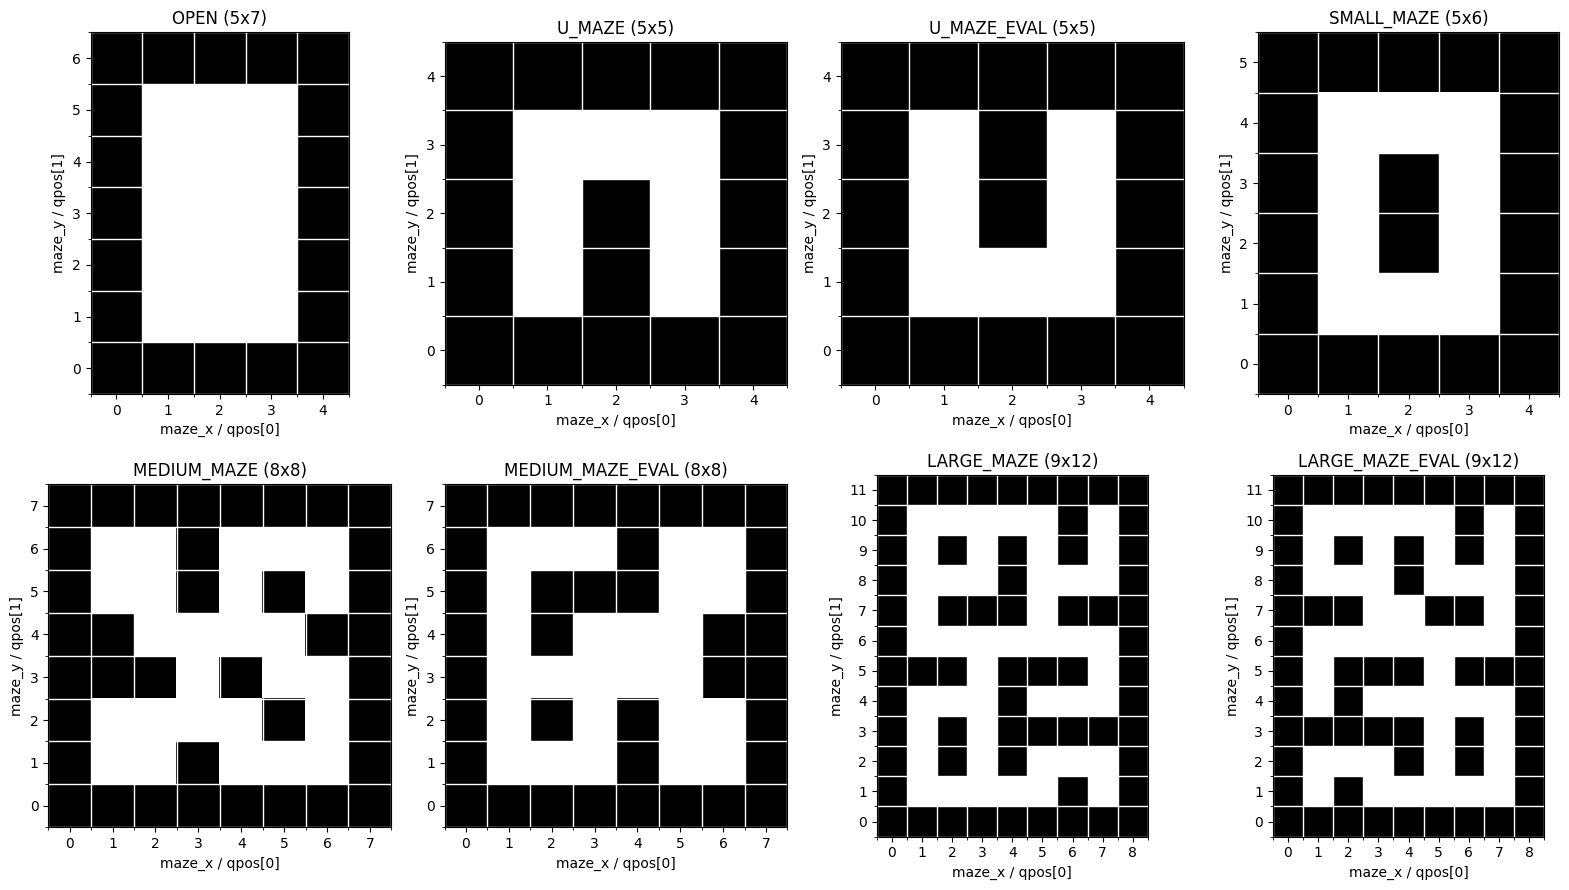

In [112]:
fig, axes = plt.subplots(2, 4, figsize=(16, 9))
axes = axes.ravel()

for ax, maze_name in zip(axes, maze_names):
    rows = maze_rows_by_name[str(maze_name)]
    maze = np.array([[1 if ch == "#" else 0 for ch in row] for row in rows], dtype=np.int32)
    ax.imshow(
        maze.T,
        origin="lower",
        cmap="Greys",
        vmin=0,
        vmax=1,
        extent=(-0.5, maze.shape[0] - 0.5, -0.5, maze.shape[1] - 0.5),
    )
    ax.set_title(f"{maze_name} ({maze.shape[0]}x{maze.shape[1]})")
    ax.set_xticks(np.arange(maze.shape[0]))
    ax.set_yticks(np.arange(maze.shape[1]))
    ax.set_xticks(np.arange(-0.5, maze.shape[0], 1), minor=True)
    ax.set_yticks(np.arange(-0.5, maze.shape[1], 1), minor=True)
    ax.grid(which="minor", color="white", linewidth=1.0)
    ax.set_xlabel("maze_x / qpos[0]")
    ax.set_ylabel("maze_y / qpos[1]")

for ax in axes[len(maze_names):]:
    ax.axis("off")

plt.tight_layout()
plt.show()



In [113]:
maze_summary = {
    str(name): {"grid_shape": [len(rows), len(rows[0])], "ascii": rows}
    for name, rows in maze_rows_by_name.items()
}
maze_summary


{'OPEN': {'grid_shape': [5, 7],
  'ascii': ['#######', '#OOOOO#', '#OOGOO#', '#OOOOO#', '#######']},
 'U_MAZE': {'grid_shape': [5, 5],
  'ascii': ['#####', '#GOO#', '###O#', '#OOO#', '#####']},
 'U_MAZE_EVAL': {'grid_shape': [5, 5],
  'ascii': ['#####', '#OOG#', '#O###', '#OOO#', '#####']},
 'SMALL_MAZE': {'grid_shape': [5, 6],
  'ascii': ['######', '#OOOO#', '#O##O#', '#OOOO#', '######']},
 'MEDIUM_MAZE': {'grid_shape': [8, 8],
  'ascii': ['########',
   '#OO##OO#',
   '#OO#OOO#',
   '##OOO###',
   '#OO#OOO#',
   '#O#OO#O#',
   '#OOO#OG#',
   '########']},
 'MEDIUM_MAZE_EVAL': {'grid_shape': [8, 8],
  'ascii': ['########',
   '#OOOOOG#',
   '#O#O##O#',
   '#OOOO#O#',
   '###OO###',
   '#OOOOOO#',
   '#OO##OO#',
   '########']},
 'LARGE_MAZE': {'grid_shape': [9, 12],
  'ascii': ['############',
   '#OOOO#OOOOO#',
   '#O##O#O#O#O#',
   '#OOOOOO#OOO#',
   '#O####O###O#',
   '#OO#O#OOOOO#',
   '##O#O#O#O###',
   '#OO#OOO#OGO#',
   '############']},
 'LARGE_MAZE_EVAL': {'grid_shape': [9, 1

## Discrete trajectory paths

These are discretized **cell paths** extracted from the Maze2D Minari dataset.
They only store the ordered path cells for each episode, not the original continuous actions.


In [114]:
TRAJECTORY_DATASET_PATH = Path("maze2d_discrete_trajectory_paths_8x8.npz")
trajectory_dataset = np.load(TRAJECTORY_DATASET_PATH, allow_pickle=True)
trajectory_maze_name = str(trajectory_dataset["maze_name"][0])
trajectory_coordinate_convention = str(trajectory_dataset["coordinate_convention"][0]) if "coordinate_convention" in trajectory_dataset else "unknown"
trajectory_maze = trajectory_dataset["maze"]
trajectory_grid_shape = tuple(int(v) for v in trajectory_dataset["grid_shape"])
trajectory_episode_ids = trajectory_dataset["episode_ids"]
trajectory_path_lengths = trajectory_dataset["path_lengths"]
trajectory_goal_cells = trajectory_dataset["goal_cells"]
trajectory_paths = trajectory_dataset["paths"]

wall_hit_count = sum(
    any(trajectory_maze[tuple(cell)] == 1 for cell in np.asarray(path_cells, dtype=np.int16))
    for path_cells in trajectory_paths
)

print("Trajectory dataset path:", TRAJECTORY_DATASET_PATH)
print("Maze name:", trajectory_maze_name)
print("Coordinate convention:", trajectory_coordinate_convention)
print("Grid shape:", trajectory_grid_shape)
print("Number of stored paths:", len(trajectory_paths))
print("Path length range:", int(trajectory_path_lengths.min()), "to", int(trajectory_path_lengths.max()))
print("Episodes whose stored discrete path hits a wall cell:", int(wall_hit_count))



Trajectory dataset path: maze2d_discrete_trajectory_paths_8x8.npz
Maze name: MEDIUM_MAZE_EVAL
Coordinate convention: logical_qpos_xy
Grid shape: (8, 8)
Number of stored paths: 12560
Path length range: 1 to 14
Episodes whose stored discrete path hits a wall cell: 0


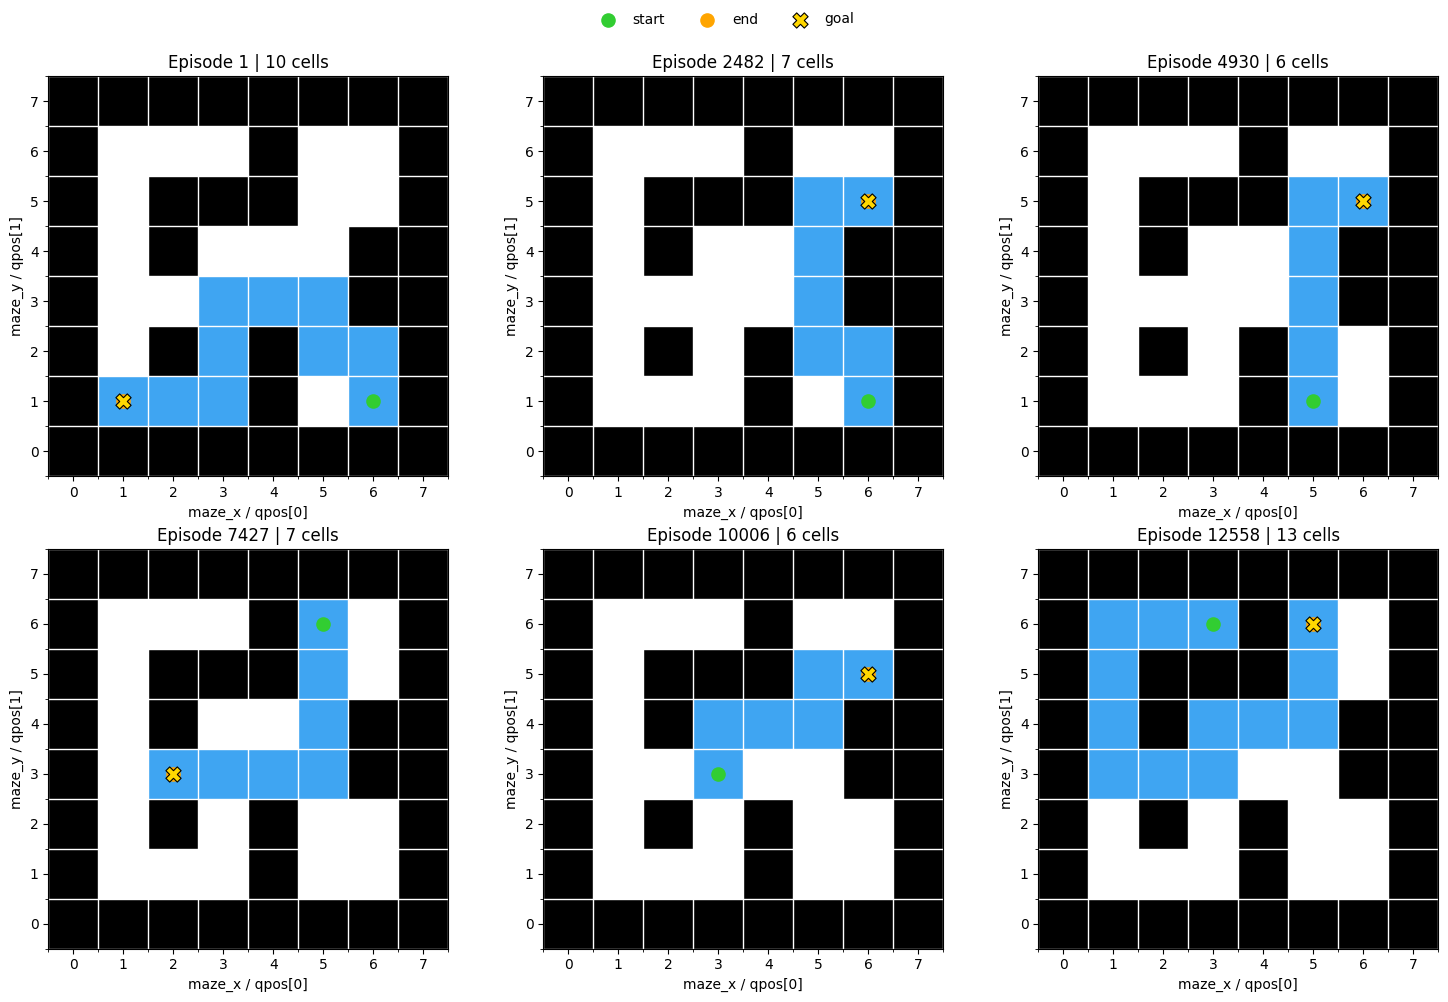

In [115]:
num_examples = min(6, len(trajectory_paths))
candidate_indices = np.flatnonzero(trajectory_path_lengths >= np.median(trajectory_path_lengths))
if len(candidate_indices) >= num_examples:
    sample_indices = candidate_indices[np.linspace(0, len(candidate_indices) - 1, num_examples, dtype=int)]
else:
    sample_indices = np.linspace(0, len(trajectory_paths) - 1, num_examples, dtype=int)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = np.asarray(axes).ravel()

for ax, sample_idx in zip(axes, sample_indices):
    path_cells = np.asarray(trajectory_paths[int(sample_idx)], dtype=np.int16)
    goal_cell = trajectory_goal_cells[int(sample_idx)]
    overlay = np.ones((trajectory_maze.shape[1], trajectory_maze.shape[0], 3), dtype=np.float32)
    overlay[trajectory_maze.T == 1] = np.array([0.0, 0.0, 0.0], dtype=np.float32)
    visited_cells = np.unique(path_cells, axis=0)
    for maze_x, maze_y in visited_cells:
        overlay[maze_y, maze_x] = np.array([0.25, 0.65, 0.95], dtype=np.float32)

    ax.imshow(
        overlay,
        origin="lower",
        extent=(-0.5, trajectory_maze.shape[0] - 0.5, -0.5, trajectory_maze.shape[1] - 0.5),
    )
    ax.scatter(path_cells[0, 0], path_cells[0, 1], c="limegreen", s=90, label="start")
    ax.scatter(path_cells[-1, 0], path_cells[-1, 1], c="orange", s=90, label="end")
    ax.scatter(goal_cell[0], goal_cell[1], c="gold", s=120, marker="X", edgecolors="black", linewidths=0.8, label="goal")
    ax.set_title(f"Episode {int(trajectory_episode_ids[int(sample_idx)])} | {int(trajectory_path_lengths[int(sample_idx)])} cells")
    ax.set_xticks(np.arange(trajectory_grid_shape[0]))
    ax.set_yticks(np.arange(trajectory_grid_shape[1]))
    ax.set_xticks(np.arange(-0.5, trajectory_grid_shape[0], 1), minor=True)
    ax.set_yticks(np.arange(-0.5, trajectory_grid_shape[1], 1), minor=True)
    ax.grid(which="minor", color="white", linewidth=1.0)
    ax.set_xlabel("maze_x / qpos[0]")
    ax.set_ylabel("maze_y / qpos[1]")

for ax in axes[num_examples:]:
    ax.axis("off")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=3, frameon=False)
plt.tight_layout(rect=(0, 0, 1, 0.96))
plt.show()



## Discrete transition dataset

This section converts each discrete cell-path episode into a **Minari-like discrete transition dataset**.
- observations store discrete cell coordinates `(maze_x, maze_y)` with shape `(T, 2)`
- actions store discrete moves `(delta_x, delta_y)` with each component in `{-1, 0, 1}`
- `infos_qpos` stores the same discrete cell coordinates as `observations`
- `infos_goal` stores the repeated goal cell coordinates with shape `(T, 2)`
- rewards are all zero to mirror the original Maze2D dataset convention more closely
- `truncated=True` only on the final row of each episode
- no velocity fields are stored, because this dataset is intended for discrete models


In [116]:
DISCRETE_TRANSITION_DATASET_PATH = Path("maze2d_discrete_8x8_minari_like.npz")


def path_to_discrete_actions(path_cells):
    path_cells = np.asarray(path_cells, dtype=np.int16)
    if len(path_cells) <= 1:
        return np.zeros((0, 2), dtype=np.int8)

    actions = np.diff(path_cells, axis=0).astype(np.int8)
    manhattan = np.abs(actions).sum(axis=1)
    if not np.all(manhattan == 1):
        bad_idx = np.flatnonzero(manhattan != 1)[:5]
        raise ValueError(f"Found non-cardinal discrete moves at steps {bad_idx.tolist()}")
    if not np.all(np.isin(actions, (-1, 0, 1))):
        raise ValueError("Discrete actions must stay in {-1, 0, 1} for each axis.")
    return actions


def build_discrete_transition_dataset(paths, goal_cells, episode_ids, grid_shape, maze, maze_name, coordinate_convention):
    num_episodes = len(paths)
    observations = np.empty(num_episodes, dtype=object)
    actions = np.empty(num_episodes, dtype=object)
    rewards = np.empty(num_episodes, dtype=object)
    terminations = np.empty(num_episodes, dtype=object)
    truncations = np.empty(num_episodes, dtype=object)
    infos_qpos = np.empty(num_episodes, dtype=object)
    infos_goal = np.empty(num_episodes, dtype=object)
    path_cells_xy = np.empty(num_episodes, dtype=object)
    observation_lengths = np.zeros(num_episodes, dtype=np.int32)
    action_lengths = np.zeros(num_episodes, dtype=np.int32)
    start_cells = np.zeros((num_episodes, 2), dtype=np.int16)
    end_cells = np.zeros((num_episodes, 2), dtype=np.int16)
    goal_cells_xy = np.zeros((num_episodes, 2), dtype=np.int16)

    for i, path_cells in enumerate(paths):
        path_cells = np.asarray(path_cells, dtype=np.int16)
        goal_cell = np.asarray(goal_cells[i], dtype=np.int16)
        act = path_to_discrete_actions(path_cells)

        obs_xy = path_cells.astype(np.int16)
        goal_xy = np.repeat(goal_cell[None, :], len(path_cells), axis=0).astype(np.int16)

        padded_actions = np.zeros((len(path_cells), 2), dtype=np.int8)
        if len(act) > 0:
            padded_actions[:-1] = act

        transition_rewards = np.zeros(len(path_cells), dtype=np.float32)
        transition_terminations = np.zeros(len(path_cells), dtype=bool)
        transition_truncations = np.zeros(len(path_cells), dtype=bool)
        if len(path_cells) > 0:
            transition_truncations[-1] = True

        observations[i] = obs_xy
        actions[i] = padded_actions
        rewards[i] = transition_rewards
        terminations[i] = transition_terminations
        truncations[i] = transition_truncations
        infos_qpos[i] = obs_xy.copy()
        infos_goal[i] = goal_xy
        path_cells_xy[i] = path_cells
        observation_lengths[i] = len(obs_xy)
        action_lengths[i] = len(padded_actions)
        start_cells[i] = obs_xy[0]
        end_cells[i] = obs_xy[-1]
        goal_cells_xy[i] = goal_cell

    return {
        "maze_name": np.array([maze_name]),
        "coordinate_convention": np.array([coordinate_convention]),
        "state_encoding": np.array(["(maze_x, maze_y) discrete cell coordinates"]),
        "action_encoding": np.array(["(delta_x, delta_y) with each component in {-1,0,1}; final action padded with (0,0)"]),
        "grid_shape": np.asarray(grid_shape, dtype=np.int32),
        "maze": np.asarray(maze, dtype=np.int8),
        "episode_ids": np.asarray(episode_ids, dtype=np.int32),
        "observation_lengths": observation_lengths,
        "action_lengths": action_lengths,
        "start_cells": start_cells,
        "end_cells": end_cells,
        "goal_cells": goal_cells_xy,
        "observations": observations,
        "actions": actions,
        "rewards": rewards,
        "terminations": terminations,
        "truncations": truncations,
        "infos_qpos": infos_qpos,
        "infos_goal": infos_goal,
        "path_cells_xy": path_cells_xy,
    }


discrete_transition_dataset = build_discrete_transition_dataset(
    paths=trajectory_paths,
    goal_cells=trajectory_goal_cells,
    episode_ids=trajectory_episode_ids,
    grid_shape=trajectory_grid_shape,
    maze=trajectory_maze,
    maze_name=trajectory_maze_name,
    coordinate_convention=trajectory_coordinate_convention,
)

np.savez(DISCRETE_TRANSITION_DATASET_PATH, **discrete_transition_dataset)

non_cardinal_action_count = sum(
    int(np.sum(np.abs(np.asarray(actions_xy, dtype=np.int8)[:-1]).sum(axis=1) != 1))
    for actions_xy in discrete_transition_dataset["actions"]
    if len(np.asarray(actions_xy, dtype=np.int8)) > 1
)
terminal_episode_count = int(
    sum(bool(np.asarray(term, dtype=bool)[-1]) if len(np.asarray(term, dtype=bool)) else False for term in discrete_transition_dataset["terminations"])
)
truncated_episode_count = int(
    sum(bool(np.asarray(trunc, dtype=bool)[-1]) if len(np.asarray(trunc, dtype=bool)) else False for trunc in discrete_transition_dataset["truncations"])
)

discrete_transition_summary = pd.DataFrame(
    [
        (
            str(DISCRETE_TRANSITION_DATASET_PATH),
            discrete_transition_dataset["maze_name"][0],
            discrete_transition_dataset["coordinate_convention"][0],
            discrete_transition_dataset["state_encoding"][0],
            len(discrete_transition_dataset["episode_ids"]),
            tuple(int(v) for v in discrete_transition_dataset["grid_shape"]),
            int(discrete_transition_dataset["observation_lengths"].min()),
            float(np.median(discrete_transition_dataset["observation_lengths"])),
            int(discrete_transition_dataset["observation_lengths"].max()),
            int(discrete_transition_dataset["action_lengths"].min()),
            float(np.median(discrete_transition_dataset["action_lengths"])),
            int(discrete_transition_dataset["action_lengths"].max()),
            int(non_cardinal_action_count),
            int(terminal_episode_count),
            int(truncated_episode_count),
        )
    ],
    columns=[
        "path",
        "maze_name",
        "coordinate_convention",
        "state_encoding",
        "episodes",
        "grid_shape",
        "min_observation_length",
        "median_observation_length",
        "max_observation_length",
        "min_action_length",
        "median_action_length",
        "max_action_length",
        "non_cardinal_action_count",
        "terminal_episode_count",
        "truncated_episode_count",
    ],
)

print("Saved discrete transition dataset to:", DISCRETE_TRANSITION_DATASET_PATH)
display(discrete_transition_summary)




Saved discrete transition dataset to: maze2d_discrete_8x8_minari_like.npz


,path,maze_name,coordinate_convention,state_encoding,episodes,grid_shape,min_observation_length,median_observation_length,max_observation_length,min_action_length,median_action_length,max_action_length,non_cardinal_action_count,terminal_episode_count,truncated_episode_count
0,maze2d_discrete_8x8_minari_like.npz,MEDIUM_MAZE_EVAL,logical_qpos_xy,"(maze_x, maze_y) discrete cell coordinates",12560,"(8, 8)",1,6.0,14,1,6.0,14,0,0,12560


In [117]:
PREVIEW_EPISODE_INDEX = int(sample_indices[0])

preview_episode_id = int(discrete_transition_dataset["episode_ids"][PREVIEW_EPISODE_INDEX])
preview_observations = np.asarray(discrete_transition_dataset["observations"][PREVIEW_EPISODE_INDEX], dtype=np.int16)
preview_qpos = np.asarray(discrete_transition_dataset["infos_qpos"][PREVIEW_EPISODE_INDEX], dtype=np.int16)
preview_goal = np.asarray(discrete_transition_dataset["infos_goal"][PREVIEW_EPISODE_INDEX], dtype=np.int16)
preview_actions = np.asarray(discrete_transition_dataset["actions"][PREVIEW_EPISODE_INDEX], dtype=np.int8)
preview_rewards = np.asarray(discrete_transition_dataset["rewards"][PREVIEW_EPISODE_INDEX], dtype=np.float32)
preview_terminations = np.asarray(discrete_transition_dataset["terminations"][PREVIEW_EPISODE_INDEX], dtype=bool)
preview_truncations = np.asarray(discrete_transition_dataset["truncations"][PREVIEW_EPISODE_INDEX], dtype=bool)

preview_table = pd.DataFrame(
    {
        "t": np.arange(len(preview_observations), dtype=np.int32),
        "obs_x": preview_observations[:, 0],
        "obs_y": preview_observations[:, 1],
        "qpos_x": preview_qpos[:, 0],
        "qpos_y": preview_qpos[:, 1],
        "goal_x": preview_goal[:, 0],
        "goal_y": preview_goal[:, 1],
        "action_x": preview_actions[:, 0],
        "action_y": preview_actions[:, 1],
        "reward": preview_rewards,
        "terminated": preview_terminations,
        "truncated": preview_truncations,
    }
)

preview_summary = {
    "episode_id": preview_episode_id,
    "observations_shape": discrete_transition_dataset["observations"][PREVIEW_EPISODE_INDEX].shape,
    "actions_shape": discrete_transition_dataset["actions"][PREVIEW_EPISODE_INDEX].shape,
    "goal_shape": discrete_transition_dataset["infos_goal"][PREVIEW_EPISODE_INDEX].shape,
    "qpos_shape": discrete_transition_dataset["infos_qpos"][PREVIEW_EPISODE_INDEX].shape,
    "info_keys": ["goal", "qpos"],
}

print(preview_summary)
preview_table.head(12)



{'episode_id': 1, 'observations_shape': (10, 2), 'actions_shape': (10, 2), 'goal_shape': (10, 2), 'qpos_shape': (10, 2), 'info_keys': ['goal', 'qpos']}


,t,obs_x,obs_y,qpos_x,qpos_y,goal_x,goal_y,action_x,action_y,reward,terminated,truncated
0,0,6,1,6,1,1,1,0,1,0.0,False,False
1,1,6,2,6,2,1,1,-1,0,0.0,False,False
2,2,5,2,5,2,1,1,0,1,0.0,False,False
3,3,5,3,5,3,1,1,-1,0,0.0,False,False
4,4,4,3,4,3,1,1,-1,0,0.0,False,False
5,5,3,3,3,3,1,1,0,-1,0.0,False,False
6,6,3,2,3,2,1,1,0,-1,0.0,False,False
7,7,3,1,3,1,1,1,-1,0,0.0,False,False
8,8,2,1,2,1,1,1,-1,0,0.0,False,False
9,9,1,1,1,1,1,1,0,0,0.0,False,True


## Episode 1 final-step check

This plot shows the **last 4 discrete timesteps of episode 1** so the padded final row can be checked directly.


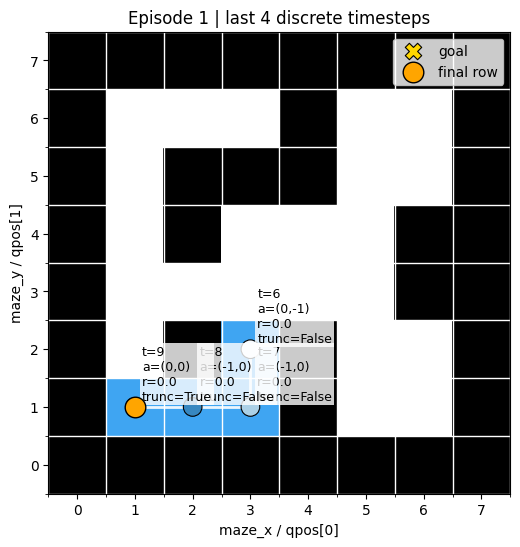

,t,obs_x,obs_y,action_x,action_y,reward,truncated
0,6,3,2,0,-1,0.0,False
1,7,3,1,-1,0,0.0,False
2,8,2,1,-1,0,0.0,False
3,9,1,1,0,0,0.0,True


In [118]:
EPISODE_ID_TO_CHECK = 1

episode_match = np.flatnonzero(discrete_transition_dataset["episode_ids"] == EPISODE_ID_TO_CHECK)
if len(episode_match) == 0:
    raise ValueError(f"Episode id {EPISODE_ID_TO_CHECK} is not present in the discrete dataset.")

episode_idx = int(episode_match[0])
check_obs = np.asarray(discrete_transition_dataset["observations"][episode_idx], dtype=np.int16)
check_actions = np.asarray(discrete_transition_dataset["actions"][episode_idx], dtype=np.int8)
check_rewards = np.asarray(discrete_transition_dataset["rewards"][episode_idx], dtype=np.float32)
check_trunc = np.asarray(discrete_transition_dataset["truncations"][episode_idx], dtype=bool)
check_goal = np.asarray(discrete_transition_dataset["infos_goal"][episode_idx], dtype=np.int16)

tail_count = min(4, len(check_obs))
tail_slice = slice(len(check_obs) - tail_count, len(check_obs))
tail_steps = np.arange(len(check_obs), dtype=np.int32)[tail_slice]
tail_obs = check_obs[tail_slice]
tail_actions = check_actions[tail_slice]
tail_rewards = check_rewards[tail_slice]
tail_trunc = check_trunc[tail_slice]
goal_cell = check_goal[-1]

overlay = np.ones((trajectory_maze.shape[1], trajectory_maze.shape[0], 3), dtype=np.float32)
overlay[trajectory_maze.T == 1] = np.array([0.0, 0.0, 0.0], dtype=np.float32)
for maze_x, maze_y in tail_obs:
    overlay[maze_y, maze_x] = np.array([0.25, 0.65, 0.95], dtype=np.float32)

fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(
    overlay,
    origin="lower",
    extent=(-0.5, trajectory_maze.shape[0] - 0.5, -0.5, trajectory_maze.shape[1] - 0.5),
)
ax.scatter(goal_cell[0], goal_cell[1], c="gold", s=140, marker="X", edgecolors="black", linewidths=0.8, label="goal")
ax.plot(tail_obs[:, 0], tail_obs[:, 1], color="white", linewidth=2.0, alpha=0.9)
scatter = ax.scatter(
    tail_obs[:, 0],
    tail_obs[:, 1],
    c=np.arange(tail_count),
    cmap="Blues",
    s=180,
    edgecolors="black",
    linewidths=0.8,
    zorder=3,
)
ax.scatter(tail_obs[-1, 0], tail_obs[-1, 1], c="orange", s=220, edgecolors="black", linewidths=1.0, zorder=4, label="final row")

for local_idx, (t, cell, action, reward_value, trunc_value) in enumerate(zip(tail_steps, tail_obs, tail_actions, tail_rewards, tail_trunc)):
    label = f"t={int(t)}\na=({int(action[0])},{int(action[1])})\nr={float(reward_value):.1f}\ntrunc={bool(trunc_value)}"
    ax.text(cell[0] + 0.12, cell[1] + 0.12, label, fontsize=9, color="black", bbox=dict(facecolor="white", alpha=0.8, edgecolor="none", pad=1.5))

ax.set_title(f"Episode {EPISODE_ID_TO_CHECK} | last {tail_count} discrete timesteps")
ax.set_xlabel("maze_x / qpos[0]")
ax.set_ylabel("maze_y / qpos[1]")
ax.set_xticks(np.arange(trajectory_grid_shape[0]))
ax.set_yticks(np.arange(trajectory_grid_shape[1]))
ax.set_xticks(np.arange(-0.5, trajectory_grid_shape[0], 1), minor=True)
ax.set_yticks(np.arange(-0.5, trajectory_grid_shape[1], 1), minor=True)
ax.grid(which="minor", color="white", linewidth=1.0)
ax.set_xlim(-0.5, trajectory_grid_shape[0] - 0.5)
ax.set_ylim(-0.5, trajectory_grid_shape[1] - 0.5)
ax.legend(loc="upper right")
plt.show()

pd.DataFrame(
    {
        "t": tail_steps,
        "obs_x": tail_obs[:, 0],
        "obs_y": tail_obs[:, 1],
        "action_x": tail_actions[:, 0],
        "action_y": tail_actions[:, 1],
        "reward": tail_rewards,
        "truncated": tail_trunc,
    }
)


## Transformer input sequence example

One compact way to feed a maze trajectory into a transformer is to keep the conditioning fields at fixed positions, followed by alternating state and action tokens:

```python
input_ids = [
    MAZE_2,
    STATE_26,
    STATE_9,
    STATE_26,
    ACTION_UP,
    STATE_25,
    ACTION_UP,
    STATE_17,
    ACTION_LEFT,
    STATE_9,
]
```

- `MAZE_2` identifies which maze layout this example belongs to. If the model is trained on multiple mazes, this token tells it which wall/corridor structure to condition on.
- The first `STATE_26` is the start cell. The cell id is an encoded `(x, y)` grid position.
- `STATE_9` at index 2 is the goal cell. This tells the model where the path should end.
- The second `STATE_26` begins the actual trajectory. It is the current position at timestep 0.
- `ACTION_UP` is the action taken from `STATE_26`.
- `STATE_25` is the next observed state after taking `ACTION_UP`.
- The next `ACTION_UP` is the action taken from `STATE_25`.
- `STATE_17` is the next observed state.
- `ACTION_LEFT` is the action taken from `STATE_17`.
- The final `STATE_9` is the reached goal state.

For **action prediction**, labels should only be active at the **action-token positions** in the trajectory part. The maze id, start cell, goal cell, and state tokens act as conditioning context, so their labels can be set to `-100` and ignored by `CrossEntropyLoss(ignore_index=-100)`.


## Transformer-ready token dataset

This section converts the discrete episode dataset into **padded GPT-style token sequences** with `input_ids`, `labels`, and `attention_mask`, ready to feed into a causal transformer.


In [119]:
TRANSFORMER_READY_DATASET_PATH = Path("maze2d_discrete_8x8_transformer_ready.npz")

PAD_TOKEN_ID = 0
MAZE_TOKEN_OFFSET = 1
NUM_MAZE_TOKENS = 1
STATE_TOKEN_OFFSET = MAZE_TOKEN_OFFSET + NUM_MAZE_TOKENS
NUM_STATE_TOKENS = int(trajectory_grid_shape[0] * trajectory_grid_shape[1])
ACTION_TOKEN_OFFSET = STATE_TOKEN_OFFSET + NUM_STATE_TOKENS
ACTION_TOKEN_NAMES = np.array(["UP", "DOWN", "LEFT", "RIGHT", "STAY"])
ACTION_DELTAS = np.asarray([
    [0, 1],
    [0, -1],
    [-1, 0],
    [1, 0],
    [0, 0],
], dtype=np.int8)
ACTION_DELTA_TO_TOKEN = {
    tuple(int(v) for v in delta): int(ACTION_TOKEN_OFFSET + idx)
    for idx, delta in enumerate(ACTION_DELTAS)
}
ACTION_TOKEN_TO_DELTA = {
    int(ACTION_TOKEN_OFFSET + idx): tuple(int(v) for v in delta)
    for idx, delta in enumerate(ACTION_DELTAS)
}
VOCAB_SIZE = ACTION_TOKEN_OFFSET + len(ACTION_DELTAS)

TOKEN_TYPE_PAD = 0
TOKEN_TYPE_MAZE = 1
TOKEN_TYPE_START = 2
TOKEN_TYPE_GOAL = 3
TOKEN_TYPE_STATE = 4
TOKEN_TYPE_ACTION = 5


def cell_to_state_index(cell_xy, grid_shape):
    cell_xy = np.asarray(cell_xy, dtype=np.int16)
    return int(cell_xy[0]) * int(grid_shape[1]) + int(cell_xy[1])


def cell_to_state_token(cell_xy, grid_shape):
    return int(STATE_TOKEN_OFFSET + cell_to_state_index(cell_xy, grid_shape))


def action_delta_to_token(delta_xy):
    key = tuple(int(v) for v in np.asarray(delta_xy, dtype=np.int8))
    if key not in ACTION_DELTA_TO_TOKEN:
        raise ValueError(f"Unknown discrete action delta: {key}")
    return ACTION_DELTA_TO_TOKEN[key]


def decode_token(token_id):
    token_id = int(token_id)
    if token_id == PAD_TOKEN_ID:
        return "PAD"
    if MAZE_TOKEN_OFFSET <= token_id < STATE_TOKEN_OFFSET:
        return f"MAZE_{token_id - MAZE_TOKEN_OFFSET}"
    if STATE_TOKEN_OFFSET <= token_id < ACTION_TOKEN_OFFSET:
        return f"STATE_{token_id - STATE_TOKEN_OFFSET}"
    if ACTION_TOKEN_OFFSET <= token_id < VOCAB_SIZE:
        return f"ACTION_{ACTION_TOKEN_NAMES[token_id - ACTION_TOKEN_OFFSET]}"
    raise ValueError(f"Unknown token id: {token_id}")


def build_transformer_episode(obs_xy, goal_xy, action_xy, maze_token_id, grid_shape):
    obs_xy = np.asarray(obs_xy, dtype=np.int16)
    goal_xy = np.asarray(goal_xy, dtype=np.int16)
    action_xy = np.asarray(action_xy, dtype=np.int8)

    if len(obs_xy) == 0:
        raise ValueError("Episodes must contain at least one observation.")

    goal_cell = goal_xy[-1]
    start_token = cell_to_state_token(obs_xy[0], grid_shape)
    goal_token = cell_to_state_token(goal_cell, grid_shape)

    input_ids = [maze_token_id, start_token, goal_token, cell_to_state_token(obs_xy[0], grid_shape)]
    token_type_ids = [TOKEN_TYPE_MAZE, TOKEN_TYPE_START, TOKEN_TYPE_GOAL, TOKEN_TYPE_STATE]
    labels = [-100, -100, -100, -100]

    for t in range(len(obs_xy) - 1):
        action_token = action_delta_to_token(action_xy[t])
        next_state_token = cell_to_state_token(obs_xy[t + 1], grid_shape)
        input_ids.extend([action_token, next_state_token])
        token_type_ids.extend([TOKEN_TYPE_ACTION, TOKEN_TYPE_STATE])
        labels.extend([action_token, -100])

    return {
        "input_ids": np.asarray(input_ids, dtype=np.int32),
        "labels": np.asarray(labels, dtype=np.int32),
        "token_type_ids": np.asarray(token_type_ids, dtype=np.int8),
        "seq_length": int(len(input_ids)),
        "start_state_index": cell_to_state_index(obs_xy[0], grid_shape),
        "goal_state_index": cell_to_state_index(goal_cell, grid_shape),
        "end_state_index": cell_to_state_index(obs_xy[-1], grid_shape),
    }


maze_token_id = MAZE_TOKEN_OFFSET
num_episodes = len(discrete_transition_dataset["episode_ids"])
episode_input_ids = []
episode_labels = []
episode_token_types = []
sequence_lengths = np.zeros(num_episodes, dtype=np.int32)
start_state_indices = np.zeros(num_episodes, dtype=np.int32)
goal_state_indices = np.zeros(num_episodes, dtype=np.int32)
end_state_indices = np.zeros(num_episodes, dtype=np.int32)

for episode_idx in range(num_episodes):
    obs_xy = np.asarray(discrete_transition_dataset["observations"][episode_idx], dtype=np.int16)
    goal_xy = np.asarray(discrete_transition_dataset["infos_goal"][episode_idx], dtype=np.int16)
    action_xy = np.asarray(discrete_transition_dataset["actions"][episode_idx], dtype=np.int8)

    packed = build_transformer_episode(
        obs_xy=obs_xy,
        goal_xy=goal_xy,
        action_xy=action_xy,
        maze_token_id=maze_token_id,
        grid_shape=trajectory_grid_shape,
    )
    episode_input_ids.append(packed["input_ids"])
    episode_labels.append(packed["labels"])
    episode_token_types.append(packed["token_type_ids"])
    sequence_lengths[episode_idx] = packed["seq_length"]
    start_state_indices[episode_idx] = packed["start_state_index"]
    goal_state_indices[episode_idx] = packed["goal_state_index"]
    end_state_indices[episode_idx] = packed["end_state_index"]

max_seq_len = int(sequence_lengths.max())
input_ids = np.full((num_episodes, max_seq_len), PAD_TOKEN_ID, dtype=np.int32)
labels = np.full((num_episodes, max_seq_len), -100, dtype=np.int32)
attention_mask = np.zeros((num_episodes, max_seq_len), dtype=np.int8)
token_type_ids = np.full((num_episodes, max_seq_len), TOKEN_TYPE_PAD, dtype=np.int8)

for episode_idx in range(num_episodes):
    seq_len = int(sequence_lengths[episode_idx])
    input_ids[episode_idx, :seq_len] = episode_input_ids[episode_idx]
    labels[episode_idx, :seq_len] = episode_labels[episode_idx]
    token_type_ids[episode_idx, :seq_len] = episode_token_types[episode_idx]
    attention_mask[episode_idx, :seq_len] = 1

transformer_ready_dataset = {
    "input_ids": input_ids,
    "labels": labels,
    "attention_mask": attention_mask,
    "token_type_ids": token_type_ids,
    "sequence_lengths": sequence_lengths,
    "episode_ids": np.asarray(discrete_transition_dataset["episode_ids"], dtype=np.int32),
    "start_state_indices": start_state_indices,
    "goal_state_indices": goal_state_indices,
    "end_state_indices": end_state_indices,
    "maze_token_ids": np.asarray([maze_token_id], dtype=np.int32),
    "maze_name": np.asarray([trajectory_maze_name]),
    "grid_shape": np.asarray(trajectory_grid_shape, dtype=np.int32),
    "pad_token_id": np.asarray([PAD_TOKEN_ID], dtype=np.int32),
    "vocab_size": np.asarray([VOCAB_SIZE], dtype=np.int32),
    "state_token_offset": np.asarray([STATE_TOKEN_OFFSET], dtype=np.int32),
    "action_token_offset": np.asarray([ACTION_TOKEN_OFFSET], dtype=np.int32),
    "action_token_names": ACTION_TOKEN_NAMES,
    "action_deltas": ACTION_DELTAS,
    "token_type_pad": np.asarray([TOKEN_TYPE_PAD], dtype=np.int8),
    "token_type_maze": np.asarray([TOKEN_TYPE_MAZE], dtype=np.int8),
    "token_type_start": np.asarray([TOKEN_TYPE_START], dtype=np.int8),
    "token_type_goal": np.asarray([TOKEN_TYPE_GOAL], dtype=np.int8),
    "token_type_state": np.asarray([TOKEN_TYPE_STATE], dtype=np.int8),
    "token_type_action": np.asarray([TOKEN_TYPE_ACTION], dtype=np.int8),
}

np.savez_compressed(TRANSFORMER_READY_DATASET_PATH, **transformer_ready_dataset)

preview_episode_idx = int(np.flatnonzero(transformer_ready_dataset["episode_ids"] == 1)[0])
preview_seq_len = int(sequence_lengths[preview_episode_idx])
preview_input_ids = input_ids[preview_episode_idx, :preview_seq_len]
preview_labels = labels[preview_episode_idx, :preview_seq_len]
preview_token_types = token_type_ids[preview_episode_idx, :preview_seq_len]

preview_token_table = pd.DataFrame(
    {
        "pos": np.arange(preview_seq_len, dtype=np.int32),
        "token_id": preview_input_ids,
        "token": [decode_token(token_id) for token_id in preview_input_ids],
        "token_type_id": preview_token_types,
        "label": preview_labels,
        "label_token": [decode_token(token_id) if int(token_id) >= 0 else "IGNORE" for token_id in preview_labels],
    }
)

transformer_ready_summary = {
    "path": str(TRANSFORMER_READY_DATASET_PATH),
    "episodes": int(num_episodes),
    "max_seq_len": int(max_seq_len),
    "min_seq_len": int(sequence_lengths.min()),
    "median_seq_len": float(np.median(sequence_lengths)),
    "vocab_size": int(VOCAB_SIZE),
    "pad_token_id": int(PAD_TOKEN_ID),
    "state_token_offset": int(STATE_TOKEN_OFFSET),
    "action_token_offset": int(ACTION_TOKEN_OFFSET),
}

print(transformer_ready_summary)
preview_token_table.head(16)


{'path': 'maze2d_discrete_8x8_transformer_ready.npz', 'episodes': 12560, 'max_seq_len': 30, 'min_seq_len': 4, 'median_seq_len': 14.0, 'vocab_size': 71, 'pad_token_id': 0, 'state_token_offset': 2, 'action_token_offset': 66}


,pos,token_id,token,token_type_id,label,label_token
0,0,1,MAZE_0,1,-100,IGNORE
1,1,51,STATE_49,2,-100,IGNORE
2,2,11,STATE_9,3,-100,IGNORE
3,3,51,STATE_49,4,-100,IGNORE
4,4,66,ACTION_UP,5,66,ACTION_UP
5,5,52,STATE_50,4,-100,IGNORE
6,6,68,ACTION_LEFT,5,68,ACTION_LEFT
7,7,44,STATE_42,4,-100,IGNORE
8,8,66,ACTION_UP,5,66,ACTION_UP
9,9,45,STATE_43,4,-100,IGNORE


## Tiny transformer proof of concept

This section loads a small causal transformer trained on the transformer-ready Maze2D token dataset and visualises what it learned.


In [120]:
import math
import torch
import torch.nn as nn

TRANSFORMER_CHECKPOINT_PATH = Path("checkpoints/maze2d_discrete_transformer_tiny_full_20ep.pt")


class NotebookPositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(max_len, dtype=torch.float32).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2, dtype=torch.float32) * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer("pe", pe.unsqueeze(0), persistent=False)

    def forward(self, x):
        return x + self.pe[:, : x.size(1)]


class NotebookTinyCausalTransformer(nn.Module):
    def __init__(self, vocab_size, max_seq_len, d_model=64, nhead=4, num_layers=2, dim_feedforward=128, dropout=0.1, num_token_types=6):
        super().__init__()
        self.token_embed = nn.Embedding(vocab_size, d_model)
        self.type_embed = nn.Embedding(num_token_types, d_model)
        self.pos_encoder = NotebookPositionalEncoding(d_model=d_model, max_len=max_seq_len)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True,
            activation="gelu",
            norm_first=False,
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.norm = nn.LayerNorm(d_model)
        self.lm_head = nn.Linear(d_model, vocab_size)

    def forward(self, input_ids, token_type_ids, attention_mask):
        x = self.token_embed(input_ids) + self.type_embed(token_type_ids)
        x = self.pos_encoder(x)
        seq_len = input_ids.size(1)
        causal_mask = torch.triu(torch.ones((seq_len, seq_len), dtype=torch.bool, device=input_ids.device), diagonal=1)
        x = self.encoder(x, mask=causal_mask, src_key_padding_mask=~attention_mask)
        x = self.norm(x)
        return self.lm_head(x)


def shifted_action_metrics(logits, labels):
    shift_logits = logits[:, :-1, :].contiguous()
    shift_labels = labels[:, 1:].contiguous()
    valid = shift_labels != -100
    if not torch.any(valid):
        return float("nan"), float("nan")
    loss = torch.nn.functional.cross_entropy(
        shift_logits.view(-1, shift_logits.size(-1)),
        shift_labels.view(-1),
        ignore_index=-100,
    )
    preds = shift_logits.argmax(dim=-1)
    acc = (preds[valid] == shift_labels[valid]).float().mean().item()
    return float(loss.item()), float(acc)


transformer_checkpoint = torch.load(TRANSFORMER_CHECKPOINT_PATH, map_location="cpu")
transformer_model_config = dict(transformer_checkpoint["model_config"])
transformer_max_seq_len = int(transformer_model_config["max_seq_len"])
transformer_max_rollout_steps = max((transformer_max_seq_len - 4) // 2, 1)
transformer_model = NotebookTinyCausalTransformer(**transformer_model_config)
transformer_model.load_state_dict(transformer_checkpoint["model_state_dict"])
transformer_model.eval()
transformer_history = pd.DataFrame(transformer_checkpoint["history"])

transformer_tokens = np.load(TRANSFORMER_READY_DATASET_PATH, allow_pickle=True)
transformer_input_ids = torch.from_numpy(transformer_tokens["input_ids"].astype(np.int64))
transformer_labels = torch.from_numpy(transformer_tokens["labels"].astype(np.int64))
transformer_attention_mask = torch.from_numpy(transformer_tokens["attention_mask"].astype(np.bool_))
transformer_token_type_ids = torch.from_numpy(transformer_tokens["token_type_ids"].astype(np.int64))
transformer_sequence_lengths = transformer_tokens["sequence_lengths"].astype(np.int32)
transformer_episode_ids = transformer_tokens["episode_ids"].astype(np.int32)

with torch.no_grad():
    transformer_logits = transformer_model(
        input_ids=transformer_input_ids,
        token_type_ids=transformer_token_type_ids,
        attention_mask=transformer_attention_mask,
    )

full_loss, full_acc = shifted_action_metrics(transformer_logits, transformer_labels)
print({
    "checkpoint": str(TRANSFORMER_CHECKPOINT_PATH),
    "history_epochs": len(transformer_history),
    "dataset_action_loss": round(full_loss, 4),
    "dataset_action_accuracy": round(full_acc, 4),
    "max_seq_len": transformer_max_seq_len,
    "max_rollout_steps": transformer_max_rollout_steps,
})


{'checkpoint': 'checkpoints\\maze2d_discrete_transformer_tiny_full_20ep.pt', 'history_epochs': 20, 'dataset_action_loss': 0.0036, 'dataset_action_accuracy': 0.9996, 'max_seq_len': 30, 'max_rollout_steps': 13}


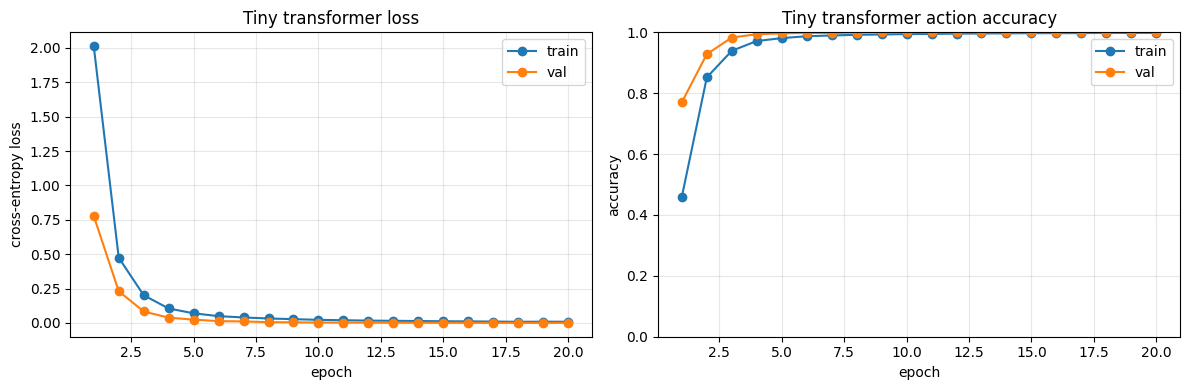

,epoch,train_loss,train_action_accuracy,val_loss,val_action_accuracy
0,1.0,2.012300,0.460291,0.778308,0.770587
1,2.0,0.474930,0.852166,0.230857,0.928454
2,3.0,0.201748,0.939363,0.083647,0.982871
3,4.0,0.105355,0.971460,0.038375,0.993827
4,5.0,0.070388,0.980956,0.024528,0.996361
5,6.0,0.049703,0.987298,0.013346,0.998335
6,7.0,0.040091,0.989676,0.011248,0.997645
7,8.0,0.032688,0.991917,0.006024,0.999025
8,9.0,0.027762,0.992989,0.004711,0.999686
9,10.0,0.022850,0.994292,0.003214,1.000000


In [121]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(transformer_history["epoch"], transformer_history["train_loss"], marker="o", label="train")
axes[0].plot(transformer_history["epoch"], transformer_history["val_loss"], marker="o", label="val")
axes[0].set_title("Tiny transformer loss")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("cross-entropy loss")
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].plot(transformer_history["epoch"], transformer_history["train_action_accuracy"], marker="o", label="train")
axes[1].plot(transformer_history["epoch"], transformer_history["val_action_accuracy"], marker="o", label="val")
axes[1].set_title("Tiny transformer action accuracy")
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("accuracy")
axes[1].set_ylim(0.0, 1.0)
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

transformer_history


In [122]:
def state_token_to_cell(token_id):
    state_index = int(token_id) - STATE_TOKEN_OFFSET
    return np.array([state_index // trajectory_grid_shape[1], state_index % trajectory_grid_shape[1]], dtype=np.int16)


def greedy_rollout_from_start(start_cell, goal_cell, max_steps=None):
    if max_steps is None:
        max_steps = transformer_max_rollout_steps
    max_steps = int(min(max_steps, transformer_max_rollout_steps))

    generated_tokens = [MAZE_TOKEN_OFFSET, cell_to_state_token(start_cell, trajectory_grid_shape), cell_to_state_token(goal_cell, trajectory_grid_shape), cell_to_state_token(start_cell, trajectory_grid_shape)]
    generated_types = [TOKEN_TYPE_MAZE, TOKEN_TYPE_START, TOKEN_TYPE_GOAL, TOKEN_TYPE_STATE]
    path = [np.asarray(start_cell, dtype=np.int16)]

    for _ in range(max_steps):
        x = torch.tensor([generated_tokens], dtype=torch.long)
        t = torch.tensor([generated_types], dtype=torch.long)
        m = torch.ones_like(x, dtype=torch.bool)
        with torch.no_grad():
            logits = transformer_model(input_ids=x, token_type_ids=t, attention_mask=m)
        action_logits = logits[0, -1, ACTION_TOKEN_OFFSET:ACTION_TOKEN_OFFSET + len(ACTION_TOKEN_NAMES)].cpu().numpy()
        current_cell = path[-1]

        valid_action_indices = []
        for action_idx, delta in enumerate(ACTION_DELTAS):
            next_cell = current_cell + delta.astype(np.int16)
            inside = 0 <= next_cell[0] < trajectory_grid_shape[0] and 0 <= next_cell[1] < trajectory_grid_shape[1]
            free = inside and trajectory_maze[tuple(next_cell)] == 0
            if free:
                valid_action_indices.append(action_idx)

        best_valid_idx = max(valid_action_indices, key=lambda idx: float(action_logits[idx]))
        delta = ACTION_DELTAS[best_valid_idx].astype(np.int16)
        next_cell = current_cell + delta
        generated_tokens.append(int(ACTION_TOKEN_OFFSET + best_valid_idx))
        generated_types.append(TOKEN_TYPE_ACTION)
        generated_tokens.append(cell_to_state_token(next_cell, trajectory_grid_shape))
        generated_types.append(TOKEN_TYPE_STATE)
        path.append(next_cell)

        if np.array_equal(next_cell, goal_cell):
            break

    return np.asarray(path, dtype=np.int16)


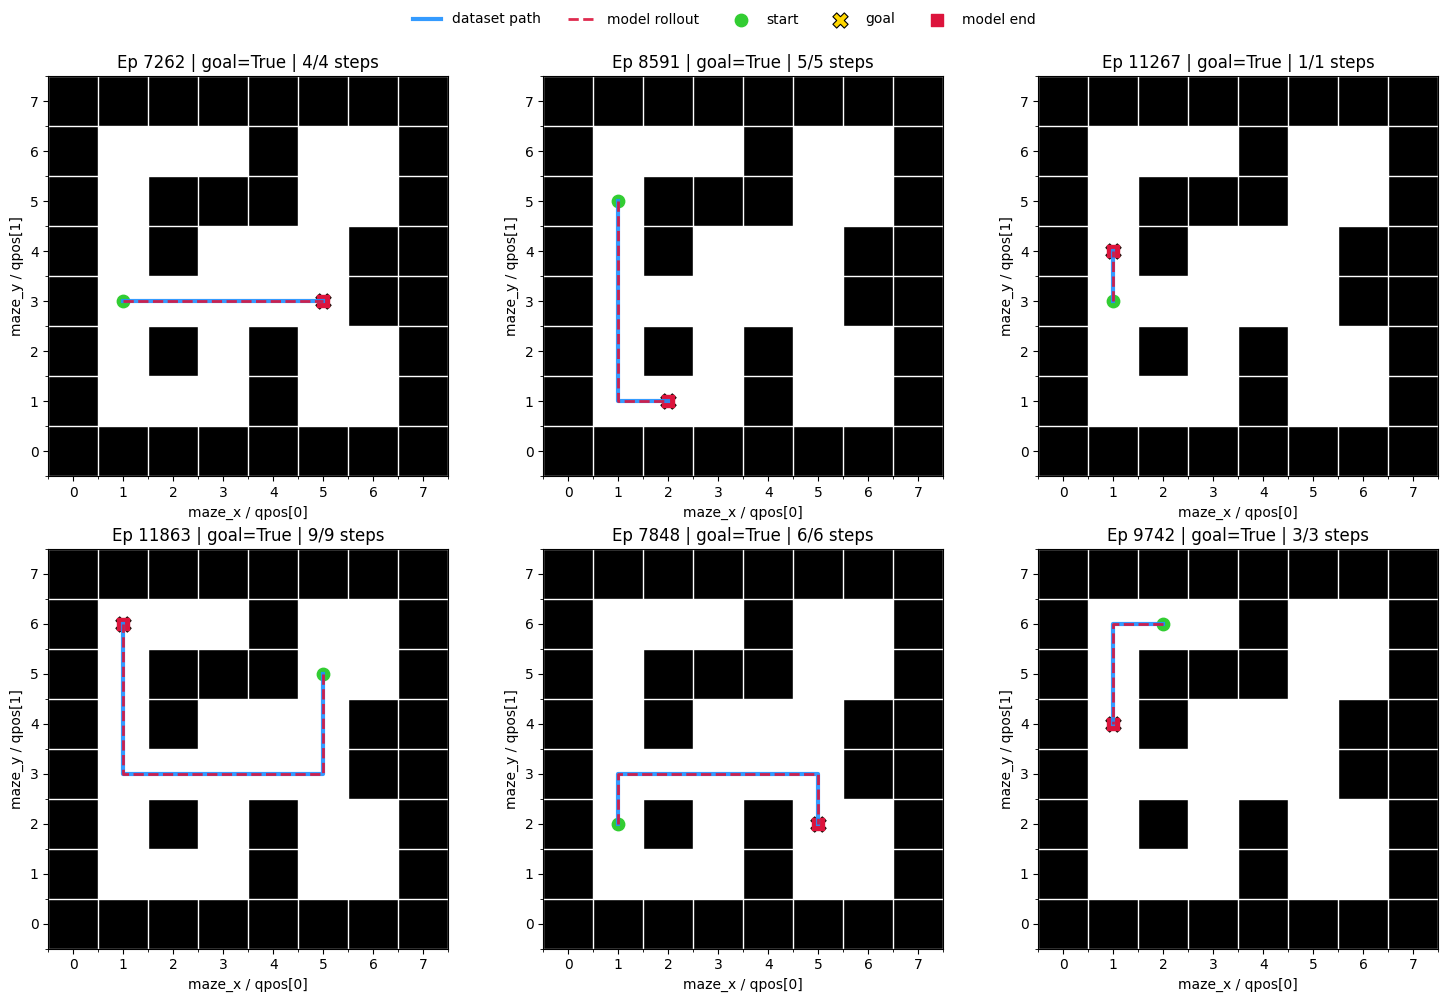

,episode_id,dataset_steps,rollout_steps,reached_goal,requested_steps,used_rollout_cap,final_cell_x,final_cell_y
0,7262,4,4,True,16,13,5,3
1,8591,5,5,True,16,13,2,1
2,11267,1,1,True,16,13,1,4
3,11863,9,9,True,20,13,1,6
4,7848,6,6,True,16,13,5,2
5,9742,3,3,True,16,13,1,4


In [123]:
rng = np.random.default_rng(7)
example_indices = rng.choice(len(trajectory_paths), size=6, replace=False)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = np.asarray(axes).ravel()
summary_rows = []

for ax, example_idx in zip(axes, example_indices):
    true_path = np.asarray(trajectory_paths[int(example_idx)], dtype=np.int16)
    goal_cell = np.asarray(trajectory_goal_cells[int(example_idx)], dtype=np.int16)
    requested_steps = max(2 * len(true_path), 16)
    pred_path = greedy_rollout_from_start(true_path[0], goal_cell, max_steps=requested_steps)

    overlay = np.ones((trajectory_maze.shape[1], trajectory_maze.shape[0], 3), dtype=np.float32)
    overlay[trajectory_maze.T == 1] = np.array([0.0, 0.0, 0.0], dtype=np.float32)
    ax.imshow(overlay, origin="lower", extent=(-0.5, trajectory_maze.shape[0] - 0.5, -0.5, trajectory_maze.shape[1] - 0.5))

    ax.plot(true_path[:, 0], true_path[:, 1], color="dodgerblue", linewidth=3.0, alpha=0.9, label="dataset path")
    ax.plot(pred_path[:, 0], pred_path[:, 1], color="crimson", linewidth=2.0, linestyle="--", alpha=0.9, label="model rollout")
    ax.scatter(true_path[0, 0], true_path[0, 1], c="limegreen", s=80, label="start")
    ax.scatter(goal_cell[0], goal_cell[1], c="gold", s=120, marker="X", edgecolors="black", linewidths=0.8, label="goal")
    ax.scatter(pred_path[-1, 0], pred_path[-1, 1], c="crimson", s=70, marker="s", label="model end")

    reached_goal = bool(np.array_equal(pred_path[-1], goal_cell))
    optimal_steps = int(max(len(true_path) - 1, 0))
    rollout_steps = int(max(len(pred_path) - 1, 0))
    ax.set_title(f"Ep {int(trajectory_episode_ids[int(example_idx)])} | goal={reached_goal} | {rollout_steps}/{optimal_steps} steps")
    ax.set_xticks(np.arange(trajectory_grid_shape[0]))
    ax.set_yticks(np.arange(trajectory_grid_shape[1]))
    ax.set_xticks(np.arange(-0.5, trajectory_grid_shape[0], 1), minor=True)
    ax.set_yticks(np.arange(-0.5, trajectory_grid_shape[1], 1), minor=True)
    ax.grid(which="minor", color="white", linewidth=1.0)
    ax.set_xlabel("maze_x / qpos[0]")
    ax.set_ylabel("maze_y / qpos[1]")

    summary_rows.append({
        "episode_id": int(trajectory_episode_ids[int(example_idx)]),
        "dataset_steps": optimal_steps,
        "rollout_steps": rollout_steps,
        "reached_goal": reached_goal,
        "requested_steps": int(requested_steps),
        "used_rollout_cap": int(transformer_max_rollout_steps),
        "final_cell_x": int(pred_path[-1, 0]),
        "final_cell_y": int(pred_path[-1, 1]),
    })

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=5, frameon=False)
plt.tight_layout(rect=(0, 0, 1, 0.96))
plt.show()

pd.DataFrame(summary_rows)


## Custom query check

This section lets you choose a **maze**, **start cell**, and **goal cell**, checks whether that exact pair appears in the multi-maze training data, and rolls out the **multi-maze transformer** only when the query is valid.


In [124]:
MULTI_MAZE_TRANSFORMER_DATASET_PATH = Path("maze2d_all_mazes_transformer_ready_holdout_large_pair.npz")
MULTI_MAZE_TRANSFORMER_CHECKPOINT_PATH = Path("checkpoints/maze2d_multi_maze_transformer_tiny_holdout_large_pair_20ep.pt")

# Available maze names: "OPEN", "U_MAZE", "U_MAZE_EVAL", "SMALL_MAZE", "MEDIUM_MAZE", "MEDIUM_MAZE_EVAL", "LARGE_MAZE", "LARGE_MAZE_EVAL"
CUSTOM_MAZE_NAME = "LARGE_MAZE"
CUSTOM_START_CELL = np.array([7, 10], dtype=np.int16)
CUSTOM_GOAL_CELL = np.array([7, 1], dtype=np.int16)

multi_maze_dataset = np.load(MULTI_MAZE_TRANSFORMER_DATASET_PATH, allow_pickle=True)
multi_maze_names = [str(name) for name in multi_maze_dataset["maze_names"]]
multi_maze_name_to_index = {name: idx for idx, name in enumerate(multi_maze_names)}

if CUSTOM_MAZE_NAME not in multi_maze_name_to_index:
    raise ValueError(f"Unknown maze name: {CUSTOM_MAZE_NAME}. Available mazes: {multi_maze_names}")

custom_maze_index = int(multi_maze_name_to_index[CUSTOM_MAZE_NAME])
custom_maze = np.asarray(multi_maze_dataset["mazes"][custom_maze_index], dtype=np.int8)
custom_grid_shape = tuple(int(v) for v in np.asarray(multi_maze_dataset["grid_shapes"][custom_maze_index], dtype=np.int32))
custom_maze_token_id = int(np.asarray(multi_maze_dataset["maze_token_ids"], dtype=np.int32)[custom_maze_index])
multi_global_grid_shape = tuple(int(v) for v in np.asarray(multi_maze_dataset["global_grid_shape"], dtype=np.int32))
multi_state_token_offset = int(np.asarray(multi_maze_dataset["state_token_offset"], dtype=np.int32)[0])
multi_action_token_offset = int(np.asarray(multi_maze_dataset["action_token_offset"], dtype=np.int32)[0])
multi_action_token_names = np.asarray(multi_maze_dataset["action_token_names"])
multi_action_deltas = np.asarray(multi_maze_dataset["action_deltas"], dtype=np.int8)

multi_transformer_checkpoint = torch.load(MULTI_MAZE_TRANSFORMER_CHECKPOINT_PATH, map_location="cpu")
multi_transformer_model_config = dict(multi_transformer_checkpoint["model_config"])
multi_transformer_model = NotebookTinyCausalTransformer(**multi_transformer_model_config)
multi_transformer_model.load_state_dict(multi_transformer_checkpoint["model_state_dict"])
multi_transformer_model.eval()
multi_transformer_max_seq_len = int(multi_transformer_model_config["max_seq_len"])
multi_transformer_max_rollout_steps = max((multi_transformer_max_seq_len - 4) // 2, 1)


def custom_cell_is_inside(cell_xy):
    return 0 <= int(cell_xy[0]) < custom_grid_shape[0] and 0 <= int(cell_xy[1]) < custom_grid_shape[1]


def custom_cell_is_free(cell_xy):
    return custom_cell_is_inside(cell_xy) and custom_maze[tuple(np.asarray(cell_xy, dtype=np.int16))] == 0


def custom_cell_to_state_token(cell_xy):
    cell_xy = np.asarray(cell_xy, dtype=np.int16)
    state_index = int(cell_xy[0]) * int(multi_global_grid_shape[1]) + int(cell_xy[1])
    return int(multi_state_token_offset + state_index)


def multi_maze_rollout(start_cell, goal_cell, max_steps=None):
    if max_steps is None:
        max_steps = multi_transformer_max_rollout_steps
    max_steps = int(min(max_steps, multi_transformer_max_rollout_steps))

    generated_tokens = [
        custom_maze_token_id,
        custom_cell_to_state_token(start_cell),
        custom_cell_to_state_token(goal_cell),
        custom_cell_to_state_token(start_cell),
    ]
    generated_types = [TOKEN_TYPE_MAZE, TOKEN_TYPE_START, TOKEN_TYPE_GOAL, TOKEN_TYPE_STATE]
    path = [np.asarray(start_cell, dtype=np.int16)]

    for _ in range(max_steps):
        x = torch.tensor([generated_tokens], dtype=torch.long)
        t = torch.tensor([generated_types], dtype=torch.long)
        m = torch.ones_like(x, dtype=torch.bool)
        with torch.no_grad():
            logits = multi_transformer_model(input_ids=x, token_type_ids=t, attention_mask=m)

        action_logits = logits[0, -1, multi_action_token_offset:multi_action_token_offset + len(multi_action_token_names)].cpu().numpy()
        current_cell = path[-1]

        valid_action_indices = []
        for action_idx, delta in enumerate(multi_action_deltas):
            next_cell = current_cell + delta.astype(np.int16)
            inside = 0 <= next_cell[0] < custom_grid_shape[0] and 0 <= next_cell[1] < custom_grid_shape[1]
            free = inside and custom_maze[tuple(next_cell)] == 0
            if free:
                valid_action_indices.append(action_idx)

        best_valid_idx = max(valid_action_indices, key=lambda idx: float(action_logits[idx]))
        delta = multi_action_deltas[best_valid_idx].astype(np.int16)
        next_cell = current_cell + delta

        generated_tokens.append(int(multi_action_token_offset + best_valid_idx))
        generated_types.append(TOKEN_TYPE_ACTION)
        generated_tokens.append(custom_cell_to_state_token(next_cell))
        generated_types.append(TOKEN_TYPE_STATE)
        path.append(next_cell)

        if np.array_equal(next_cell, goal_cell):
            break

    return np.asarray(path, dtype=np.int16)


multi_starts = np.asarray(multi_maze_dataset["start_cells"], dtype=np.int16)
multi_goals = np.asarray(multi_maze_dataset["goal_cells"], dtype=np.int16)
multi_maze_indices = np.asarray(multi_maze_dataset["maze_indices"], dtype=np.int32)

pair_matches = (
    (multi_maze_indices == custom_maze_index)
    & np.all(multi_starts == CUSTOM_START_CELL[None, :], axis=1)
    & np.all(multi_goals == CUSTOM_GOAL_CELL[None, :], axis=1)
)
custom_query_match_count = int(np.sum(pair_matches))
custom_query_in_training_data = bool(custom_query_match_count > 0)

custom_query_summary = {
    "maze_name": CUSTOM_MAZE_NAME,
    "maze_index": custom_maze_index,
    "maze_token_id": custom_maze_token_id,
    "grid_shape": custom_grid_shape,
    "start_cell": CUSTOM_START_CELL.tolist(),
    "goal_cell": CUSTOM_GOAL_CELL.tolist(),
    "start_inside": bool(custom_cell_is_inside(CUSTOM_START_CELL)),
    "goal_inside": bool(custom_cell_is_inside(CUSTOM_GOAL_CELL)),
    "start_free": bool(custom_cell_is_free(CUSTOM_START_CELL)),
    "goal_free": bool(custom_cell_is_free(CUSTOM_GOAL_CELL)),
    "pair_found_in_training_data": custom_query_in_training_data,
    "matching_dataset_episodes": custom_query_match_count,
    "max_rollout_steps": multi_transformer_max_rollout_steps,
}

print(custom_query_summary)
print(f"Pair found in training data: {custom_query_in_training_data} (matching episodes: {custom_query_match_count})")


{'maze_name': 'LARGE_MAZE', 'maze_index': 6, 'maze_token_id': 7, 'grid_shape': (9, 12), 'start_cell': [7, 10], 'goal_cell': [7, 1], 'start_inside': True, 'goal_inside': True, 'start_free': True, 'goal_free': True, 'pair_found_in_training_data': False, 'matching_dataset_episodes': 0, 'max_rollout_steps': 19}
Pair found in training data: False (matching episodes: 0)


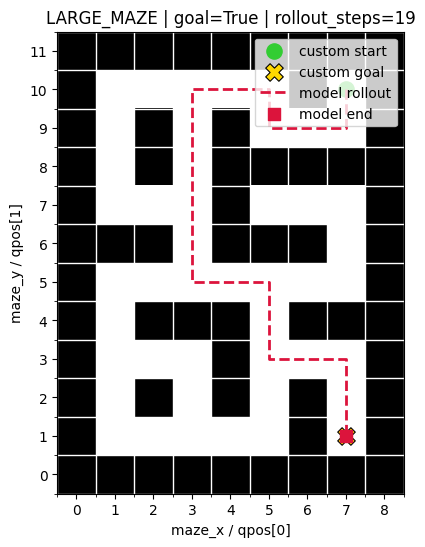

In [125]:
overlay = np.ones((custom_maze.shape[1], custom_maze.shape[0], 3), dtype=np.float32)
overlay[custom_maze.T == 1] = np.array([0.0, 0.0, 0.0], dtype=np.float32)

fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(
    overlay,
    origin="lower",
    extent=(-0.5, custom_maze.shape[0] - 0.5, -0.5, custom_maze.shape[1] - 0.5),
)

start_ok = bool(custom_cell_is_free(CUSTOM_START_CELL))
goal_ok = bool(custom_cell_is_free(CUSTOM_GOAL_CELL))

ax.scatter(CUSTOM_START_CELL[0], CUSTOM_START_CELL[1], c="limegreen" if start_ok else "orange", s=120, label="custom start")
ax.scatter(CUSTOM_GOAL_CELL[0], CUSTOM_GOAL_CELL[1], c="gold" if goal_ok else "red", s=160, marker="X", edgecolors="black", linewidths=0.8, label="custom goal")

if start_ok and goal_ok:
    custom_pred_path = multi_maze_rollout(CUSTOM_START_CELL, CUSTOM_GOAL_CELL)
    ax.plot(custom_pred_path[:, 0], custom_pred_path[:, 1], color="crimson", linewidth=2.0, linestyle="--", label="model rollout")
    ax.scatter(custom_pred_path[-1, 0], custom_pred_path[-1, 1], c="crimson", s=70, marker="s", label="model end")
    reached_goal = bool(np.array_equal(custom_pred_path[-1], CUSTOM_GOAL_CELL))
    title = f"{CUSTOM_MAZE_NAME} | goal={reached_goal} | rollout_steps={max(len(custom_pred_path) - 1, 0)}"
else:
    invalid_bits = []
    if not start_ok:
        invalid_bits.append("start is not a free cell")
    if not goal_ok:
        invalid_bits.append("goal is not a free cell")
    title = f"{CUSTOM_MAZE_NAME} invalid: " + ", ".join(invalid_bits)

ax.set_title(title)
ax.set_xlabel("maze_x / qpos[0]")
ax.set_ylabel("maze_y / qpos[1]")
ax.set_xticks(np.arange(custom_grid_shape[0]))
ax.set_yticks(np.arange(custom_grid_shape[1]))
ax.set_xticks(np.arange(-0.5, custom_grid_shape[0], 1), minor=True)
ax.set_yticks(np.arange(-0.5, custom_grid_shape[1], 1), minor=True)
ax.grid(which="minor", color="white", linewidth=1.0)
ax.legend(loc="upper right")
plt.show()


## Decoding Benchmark

This section implements **greedy decoding** and **beam search from scratch** for the held-out multi-maze transformer, then benchmarks them on seen start-goal pairs.


In [126]:
import time


def multi_maze_valid_action_candidates(current_cell, maze, grid_shape):
    candidates = []
    for action_idx, delta in enumerate(multi_action_deltas):
        next_cell = current_cell + delta.astype(np.int16)
        inside = 0 <= int(next_cell[0]) < int(grid_shape[0]) and 0 <= int(next_cell[1]) < int(grid_shape[1])
        free = inside and maze[tuple(next_cell)] == 0
        if free:
            candidates.append((action_idx, next_cell.astype(np.int16)))
    return candidates


def batched_next_action_logits(batch_tokens, batch_types):
    x = torch.tensor(batch_tokens, dtype=torch.long)
    t = torch.tensor(batch_types, dtype=torch.long)
    m = torch.ones_like(x, dtype=torch.bool)
    with torch.no_grad():
        logits = multi_transformer_model(input_ids=x, token_type_ids=t, attention_mask=m)
    return logits[:, -1, multi_action_token_offset:multi_action_token_offset + len(multi_action_token_names)].cpu().numpy()


def greedy_decode_query(maze_index, start_cell, goal_cell, max_steps=None):
    maze = np.asarray(multi_maze_dataset["mazes"][maze_index], dtype=np.int8)
    grid_shape = tuple(int(v) for v in np.asarray(multi_maze_dataset["grid_shapes"][maze_index], dtype=np.int32))
    maze_token_id = int(np.asarray(multi_maze_dataset["maze_token_ids"], dtype=np.int32)[maze_index])
    if max_steps is None:
        max_steps = multi_transformer_max_rollout_steps
    max_steps = int(min(max_steps, multi_transformer_max_rollout_steps))

    tokens = [maze_token_id, custom_cell_to_state_token(start_cell), custom_cell_to_state_token(goal_cell), custom_cell_to_state_token(start_cell)]
    types = [TOKEN_TYPE_MAZE, TOKEN_TYPE_START, TOKEN_TYPE_GOAL, TOKEN_TYPE_STATE]
    path = [np.asarray(start_cell, dtype=np.int16)]

    for _ in range(max_steps):
        logits = batched_next_action_logits([tokens], [types])[0]
        candidates = multi_maze_valid_action_candidates(path[-1], maze, grid_shape)
        best_action_idx, best_next_cell = max(candidates, key=lambda item: float(logits[item[0]]))
        tokens.extend([int(multi_action_token_offset + best_action_idx), custom_cell_to_state_token(best_next_cell)])
        types.extend([TOKEN_TYPE_ACTION, TOKEN_TYPE_STATE])
        path.append(best_next_cell)
        if np.array_equal(best_next_cell, goal_cell):
            break

    return np.asarray(path, dtype=np.int16)


def beam_decode_query(maze_index, start_cell, goal_cell, beam_width=2, max_steps=None):
    maze = np.asarray(multi_maze_dataset["mazes"][maze_index], dtype=np.int8)
    grid_shape = tuple(int(v) for v in np.asarray(multi_maze_dataset["grid_shapes"][maze_index], dtype=np.int32))
    maze_token_id = int(np.asarray(multi_maze_dataset["maze_token_ids"], dtype=np.int32)[maze_index])
    if max_steps is None:
        max_steps = multi_transformer_max_rollout_steps
    max_steps = int(min(max_steps, multi_transformer_max_rollout_steps))

    beams = [{
        "tokens": [maze_token_id, custom_cell_to_state_token(start_cell), custom_cell_to_state_token(goal_cell), custom_cell_to_state_token(start_cell)],
        "types": [TOKEN_TYPE_MAZE, TOKEN_TYPE_START, TOKEN_TYPE_GOAL, TOKEN_TYPE_STATE],
        "path": [np.asarray(start_cell, dtype=np.int16)],
        "score": 0.0,
        "done": False,
    }]

    for _ in range(max_steps):
        active = [beam for beam in beams if not beam["done"]]
        if not active:
            break

        logits_batch = batched_next_action_logits([beam["tokens"] for beam in active], [beam["types"] for beam in active])

        expanded = [beam for beam in beams if beam["done"]]
        for beam, logits in zip(active, logits_batch):
            shifted = logits - np.max(logits)
            log_probs = shifted - np.log(np.sum(np.exp(shifted)))
            candidates = multi_maze_valid_action_candidates(beam["path"][-1], maze, grid_shape)
            for action_idx, next_cell in candidates:
                done = bool(np.array_equal(next_cell, goal_cell))
                expanded.append({
                    "tokens": beam["tokens"] + [int(multi_action_token_offset + action_idx), custom_cell_to_state_token(next_cell)],
                    "types": beam["types"] + [TOKEN_TYPE_ACTION, TOKEN_TYPE_STATE],
                    "path": beam["path"] + [next_cell],
                    "score": beam["score"] + float(log_probs[action_idx]),
                    "done": done,
                })

        expanded.sort(key=lambda beam: beam["score"], reverse=True)
        beams = expanded[:beam_width]

        if any(beam["done"] for beam in beams):
            completed = [beam for beam in beams if beam["done"]]
            completed.sort(key=lambda beam: beam["score"], reverse=True)
            return np.asarray(completed[0]["path"], dtype=np.int16)

    beams.sort(key=lambda beam: beam["score"], reverse=True)
    return np.asarray(beams[0]["path"], dtype=np.int16)


def decode_query(maze_index, start_cell, goal_cell, strategy):
    if strategy == "greedy":
        return greedy_decode_query(maze_index, start_cell, goal_cell)
    if strategy == "beam_2":
        return beam_decode_query(maze_index, start_cell, goal_cell, beam_width=2)
    if strategy == "beam_3":
        return beam_decode_query(maze_index, start_cell, goal_cell, beam_width=3)
    raise ValueError(f"Unknown strategy: {strategy}")


In [127]:
BENCHMARK_MAZES = ["OPEN", "U_MAZE", "SMALL_MAZE", "MEDIUM_MAZE", "LARGE_MAZE"]
BENCHMARK_QUERIES_PER_MAZE = 20
BENCHMARK_STRATEGIES = ["greedy", "beam_2", "beam_3"]
BENCHMARK_RANDOM_SEED = 7

rng = np.random.default_rng(BENCHMARK_RANDOM_SEED)
benchmark_rows = []

all_maze_indices = np.asarray(multi_maze_dataset["maze_indices"], dtype=np.int32)
all_starts = np.asarray(multi_maze_dataset["start_cells"], dtype=np.int16)
all_goals = np.asarray(multi_maze_dataset["goal_cells"], dtype=np.int16)
all_episode_ids = np.asarray(multi_maze_dataset["episode_ids"], dtype=np.int32)

selected_queries = []
for maze_name in BENCHMARK_MAZES:
    maze_index = int(multi_maze_name_to_index[maze_name])
    candidate_indices = np.flatnonzero(all_maze_indices == maze_index)
    chosen_indices = rng.choice(candidate_indices, size=BENCHMARK_QUERIES_PER_MAZE, replace=False)
    for dataset_idx in chosen_indices:
        selected_queries.append({
            "maze_name": maze_name,
            "maze_index": maze_index,
            "episode_id": int(all_episode_ids[dataset_idx]),
            "start_cell": all_starts[dataset_idx].copy(),
            "goal_cell": all_goals[dataset_idx].copy(),
        })

for query in selected_queries:
    for strategy in BENCHMARK_STRATEGIES:
        t0 = time.perf_counter()
        pred_path = decode_query(query["maze_index"], query["start_cell"], query["goal_cell"], strategy=strategy)
        elapsed = time.perf_counter() - t0
        reached_goal = bool(np.array_equal(pred_path[-1], query["goal_cell"]))
        benchmark_rows.append({
            "maze_name": query["maze_name"],
            "episode_id": query["episode_id"],
            "start_x": int(query["start_cell"][0]),
            "start_y": int(query["start_cell"][1]),
            "goal_x": int(query["goal_cell"][0]),
            "goal_y": int(query["goal_cell"][1]),
            "strategy": strategy,
            "compute_seconds": float(elapsed),
            "steps_until_stop": int(max(len(pred_path) - 1, 0)),
            "goal_reached": reached_goal,
        })

benchmark_results = pd.DataFrame(benchmark_rows)

def avg_steps_to_goal(group):
    success_rows = group[group["goal_reached"]]
    if len(success_rows) == 0:
        return float("nan")
    return float(success_rows["steps_until_stop"].mean())

benchmark_summary = (
    benchmark_results.groupby("strategy", as_index=False)
    .apply(lambda group: pd.Series({
        "queries": int(len(group)),
        "completion_rate": float(group["goal_reached"].mean()),
        "average_steps_to_goal": avg_steps_to_goal(group),
        "average_computation_seconds": float(group["compute_seconds"].mean()),
    }), include_groups=False)
)

benchmark_per_maze_summary = (
    benchmark_results.groupby(["maze_name", "strategy"], as_index=False)
    .apply(lambda group: pd.Series({
        "queries": int(len(group)),
        "completion_rate": float(group["goal_reached"].mean()),
        "average_steps_to_goal": avg_steps_to_goal(group),
        "average_computation_seconds": float(group["compute_seconds"].mean()),
    }), include_groups=False)
)

print(benchmark_summary)
benchmark_summary


  strategy  queries  completion_rate  average_steps_to_goal  \
0   beam_2    100.0             0.97               3.958763   
1   beam_3    100.0             1.00               3.840000   
2   greedy    100.0             0.88               4.420455   

   average_computation_seconds  
0                     0.018806  
1                     0.016532  
2                     0.021919  


,strategy,queries,completion_rate,average_steps_to_goal,average_computation_seconds
0,beam_2,100.0,0.97,3.958763,0.018806
1,beam_3,100.0,1.00,3.840000,0.016532
2,greedy,100.0,0.88,4.420455,0.021919


## Failed Decoding Examples

For any decoding strategy whose completion rate is below `1.0`, this section shows **one counterexample** from the benchmark.


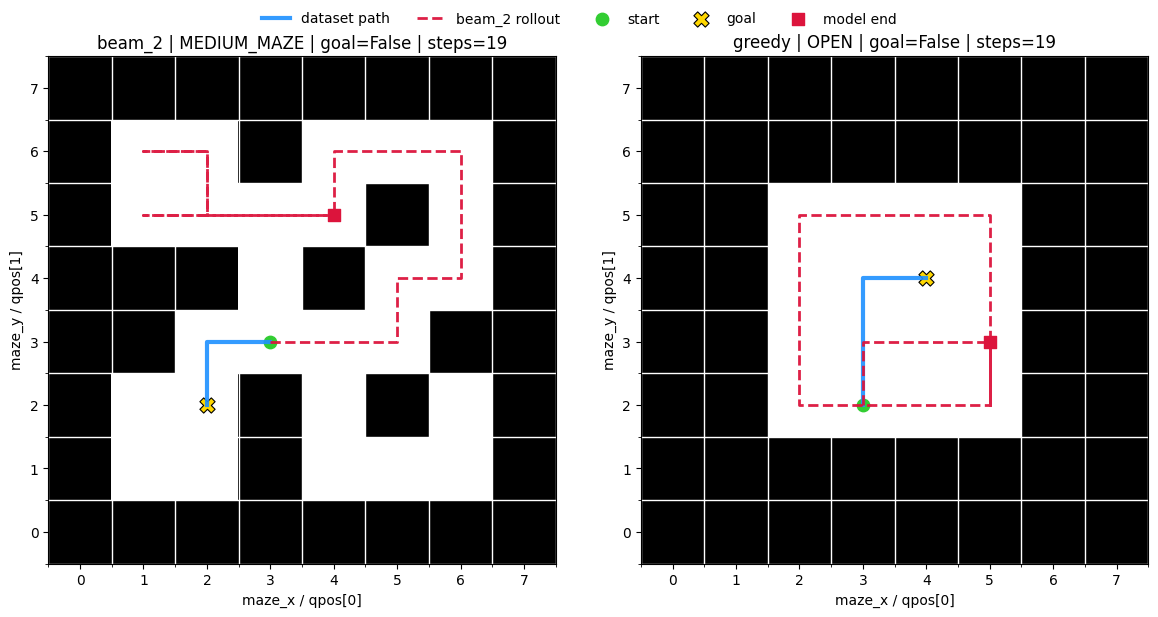

In [128]:
failing_strategies = benchmark_summary.loc[benchmark_summary["completion_rate"] < 1.0, "strategy"].tolist()

if not failing_strategies:
    print("All decoding strategies reached completion rate 1.0 on this benchmark.")
else:
    num_examples = len(failing_strategies)
    fig, axes = plt.subplots(1, num_examples, figsize=(6 * num_examples, 6))
    if num_examples == 1:
        axes = [axes]

    failure_rows = []
    for ax, strategy in zip(axes, failing_strategies):
        failed_row = benchmark_results[(benchmark_results["strategy"] == strategy) & (~benchmark_results["goal_reached"])].iloc[0]
        maze_name = str(failed_row["maze_name"])
        maze_index = int(multi_maze_name_to_index[maze_name])
        maze = np.asarray(multi_maze_dataset["mazes"][maze_index], dtype=np.int8)
        grid_shape = tuple(int(v) for v in np.asarray(multi_maze_dataset["grid_shapes"][maze_index], dtype=np.int32))
        start_cell = np.array([int(failed_row["start_x"]), int(failed_row["start_y"])], dtype=np.int16)
        goal_cell = np.array([int(failed_row["goal_x"]), int(failed_row["goal_y"])], dtype=np.int16)

        pred_path = decode_query(maze_index, start_cell, goal_cell, strategy=strategy)

        dataset_match = (
            (all_maze_indices == maze_index)
            & np.all(all_starts == start_cell[None, :], axis=1)
            & np.all(all_goals == goal_cell[None, :], axis=1)
        )
        if np.any(dataset_match):
            dataset_idx = int(np.flatnonzero(dataset_match)[0])
            true_path = np.asarray(multi_maze_dataset["paths_xy"][dataset_idx], dtype=np.int16)
        else:
            true_path = None

        overlay = np.ones((maze.shape[1], maze.shape[0], 3), dtype=np.float32)
        overlay[maze.T == 1] = np.array([0.0, 0.0, 0.0], dtype=np.float32)
        ax.imshow(overlay, origin="lower", extent=(-0.5, maze.shape[0] - 0.5, -0.5, maze.shape[1] - 0.5))

        if true_path is not None:
            ax.plot(true_path[:, 0], true_path[:, 1], color="dodgerblue", linewidth=3.0, alpha=0.9, label="dataset path")
        ax.plot(pred_path[:, 0], pred_path[:, 1], color="crimson", linewidth=2.0, linestyle="--", alpha=0.95, label=f"{strategy} rollout")
        ax.scatter(start_cell[0], start_cell[1], c="limegreen", s=80, label="start")
        ax.scatter(goal_cell[0], goal_cell[1], c="gold", s=120, marker="X", edgecolors="black", linewidths=0.8, label="goal")
        ax.scatter(pred_path[-1, 0], pred_path[-1, 1], c="crimson", s=70, marker="s", label="model end")

        ax.set_title(f"{strategy} | {maze_name} | goal=False | steps={int(max(len(pred_path) - 1, 0))}")
        ax.set_xlabel("maze_x / qpos[0]")
        ax.set_ylabel("maze_y / qpos[1]")
        ax.set_xticks(np.arange(grid_shape[0]))
        ax.set_yticks(np.arange(grid_shape[1]))
        ax.set_xticks(np.arange(-0.5, grid_shape[0], 1), minor=True)
        ax.set_yticks(np.arange(-0.5, grid_shape[1], 1), minor=True)
        ax.grid(which="minor", color="white", linewidth=1.0)

        failure_rows.append({
            "strategy": strategy,
            "maze_name": maze_name,
            "episode_id": int(failed_row["episode_id"]),
            "start_cell": start_cell.tolist(),
            "goal_cell": goal_cell.tolist(),
            "final_cell": pred_path[-1].tolist(),
            "steps_until_stop": int(max(len(pred_path) - 1, 0)),
        })

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", ncol=5, frameon=False)
    plt.tight_layout(rect=(0, 0, 1, 0.94))
    plt.show()

    pd.DataFrame(failure_rows)


## Beam-3 Better Than Greedy Example

This section shows one benchmark query where **both greedy and beam-3 reach the goal**, but **beam-3 finds a shorter path**.


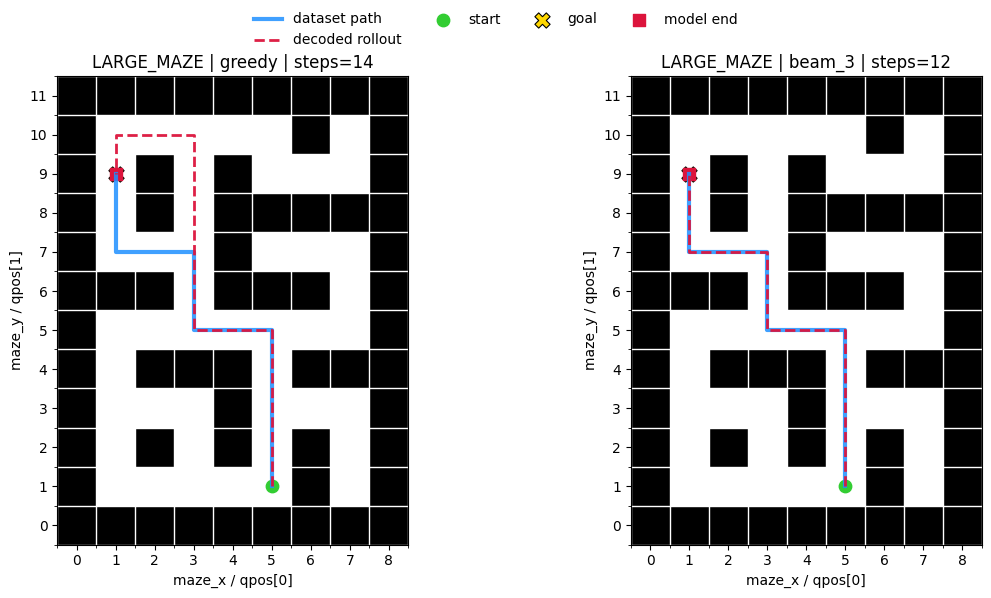

In [129]:
comparison_rows = benchmark_results.pivot_table(
    index=["maze_name", "episode_id", "start_x", "start_y", "goal_x", "goal_y"],
    columns="strategy",
    values=["goal_reached", "steps_until_stop"],
    aggfunc="first",
)
comparison_rows.columns = [f"{metric}_{strategy}" for metric, strategy in comparison_rows.columns]
comparison_rows = comparison_rows.reset_index()

beam3_better = comparison_rows[
    (comparison_rows["goal_reached_greedy"] == 1)
    & (comparison_rows["goal_reached_beam_3"] == 1)
    & (comparison_rows["steps_until_stop_beam_3"] < comparison_rows["steps_until_stop_greedy"])
].copy()

if len(beam3_better) == 0:
    print("No example found where beam-3 reaches the goal in fewer steps than greedy.")
else:
    example = beam3_better.sort_values(["maze_name", "steps_until_stop_greedy", "steps_until_stop_beam_3"], ascending=[True, False, True]).iloc[0]
    maze_name = str(example["maze_name"])
    maze_index = int(multi_maze_name_to_index[maze_name])
    maze = np.asarray(multi_maze_dataset["mazes"][maze_index], dtype=np.int8)
    grid_shape = tuple(int(v) for v in np.asarray(multi_maze_dataset["grid_shapes"][maze_index], dtype=np.int32))
    start_cell = np.array([int(example["start_x"]), int(example["start_y"])] , dtype=np.int16)
    goal_cell = np.array([int(example["goal_x"]), int(example["goal_y"])] , dtype=np.int16)

    greedy_path = decode_query(maze_index, start_cell, goal_cell, strategy="greedy")
    beam3_path = decode_query(maze_index, start_cell, goal_cell, strategy="beam_3")

    dataset_match = (
        (all_maze_indices == maze_index)
        & np.all(all_starts == start_cell[None, :], axis=1)
        & np.all(all_goals == goal_cell[None, :], axis=1)
    )
    true_path = np.asarray(multi_maze_dataset["paths_xy"][int(np.flatnonzero(dataset_match)[0])], dtype=np.int16) if np.any(dataset_match) else None

    overlay = np.ones((maze.shape[1], maze.shape[0], 3), dtype=np.float32)
    overlay[maze.T == 1] = np.array([0.0, 0.0, 0.0], dtype=np.float32)

    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    for ax, path, title in [
        (axes[0], greedy_path, f"greedy | steps={len(greedy_path) - 1}"),
        (axes[1], beam3_path, f"beam_3 | steps={len(beam3_path) - 1}"),
    ]:
        ax.imshow(overlay, origin="lower", extent=(-0.5, maze.shape[0] - 0.5, -0.5, maze.shape[1] - 0.5))
        if true_path is not None:
            ax.plot(true_path[:, 0], true_path[:, 1], color="dodgerblue", linewidth=3.0, alpha=0.85, label="dataset path")
        ax.plot(path[:, 0], path[:, 1], color="crimson", linewidth=2.0, linestyle="--", alpha=0.95, label="decoded rollout")
        ax.scatter(start_cell[0], start_cell[1], c="limegreen", s=80, label="start")
        ax.scatter(goal_cell[0], goal_cell[1], c="gold", s=120, marker="X", edgecolors="black", linewidths=0.8, label="goal")
        ax.scatter(path[-1, 0], path[-1, 1], c="crimson", s=70, marker="s", label="model end")
        ax.set_title(f"{maze_name} | {title}")
        ax.set_xlabel("maze_x / qpos[0]")
        ax.set_ylabel("maze_y / qpos[1]")
        ax.set_xticks(np.arange(grid_shape[0]))
        ax.set_yticks(np.arange(grid_shape[1]))
        ax.set_xticks(np.arange(-0.5, grid_shape[0], 1), minor=True)
        ax.set_yticks(np.arange(-0.5, grid_shape[1], 1), minor=True)
        ax.grid(which="minor", color="white", linewidth=1.0)

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", ncol=4, frameon=False)
    plt.tight_layout(rect=(0, 0, 1, 0.94))
    plt.show()

    pd.DataFrame([{
        "maze_name": maze_name,
        "episode_id": int(example["episode_id"]),
        "start_cell": start_cell.tolist(),
        "goal_cell": goal_cell.tolist(),
        "greedy_steps": int(len(greedy_path) - 1),
        "beam_3_steps": int(len(beam3_path) - 1),
        "improvement": int((len(greedy_path) - 1) - (len(beam3_path) - 1)),
    }])


## Held-out decoding evaluation

This section reports decoding performance on a deterministic 80/20 held-out split. The model is trained only on the `train_mask` queries and all decoding metrics below are measured on the disjoint `eval_mask` queries.


In [130]:
from train_maze2d_discrete_transformer import TinyCausalTransformer

HELDOUT_DATASET_PATH = Path("maze2d_all_mazes_transformer_ready_split_80_20.npz")
HELDOUT_CHECKPOINT_PATH = Path("checkpoints/maze2d_multi_maze_transformer_tiny_split80_20_20ep.pt")
HELDOUT_RESULTS_CSV = Path("beam_search_benchmark_holdout_results.csv")
HELDOUT_SUMMARY_CSV = Path("beam_search_benchmark_holdout_summary.csv")
HELDOUT_PER_MAZE_SUMMARY_CSV = Path("beam_search_benchmark_holdout_per_maze_summary.csv")

heldout_dataset = np.load(HELDOUT_DATASET_PATH, allow_pickle=True)
heldout_results = pd.read_csv(HELDOUT_RESULTS_CSV)
heldout_summary = pd.read_csv(HELDOUT_SUMMARY_CSV)
heldout_per_maze_summary = pd.read_csv(HELDOUT_PER_MAZE_SUMMARY_CSV)

heldout_checkpoint = torch.load(HELDOUT_CHECKPOINT_PATH, map_location="cpu")
heldout_model = TinyCausalTransformer(**heldout_checkpoint["model_config"])
heldout_model.load_state_dict(heldout_checkpoint["model_state_dict"])
heldout_model.eval()

heldout_train_mask = np.asarray(heldout_dataset["train_mask"], dtype=bool)
heldout_eval_mask = np.asarray(heldout_dataset["eval_mask"], dtype=bool)
heldout_maze_names = [str(x) for x in heldout_dataset["maze_names"]]
heldout_maze_name_per_episode = np.asarray(heldout_dataset["maze_name_per_episode"]).astype(str)
heldout_mazes = [np.asarray(maze, dtype=np.int8) for maze in heldout_dataset["mazes"]]
heldout_maze_indices = np.asarray(heldout_dataset["maze_indices"], dtype=np.int32)
heldout_start_cells = np.asarray(heldout_dataset["start_cells"], dtype=np.int16)
heldout_goal_cells = np.asarray(heldout_dataset["goal_cells"], dtype=np.int16)
heldout_episode_ids = np.asarray(heldout_dataset["episode_ids"], dtype=np.int32)
heldout_path_lengths = np.asarray(heldout_dataset["path_lengths"], dtype=np.int32)
heldout_maze_token_ids = np.asarray(heldout_dataset["maze_token_ids"], dtype=np.int32)
heldout_state_token_offset = int(heldout_dataset["state_token_offset"][0])
heldout_action_token_offset = int(heldout_dataset["action_token_offset"][0])
heldout_global_grid_shape = tuple(int(v) for v in np.asarray(heldout_dataset["global_grid_shape"], dtype=np.int32))
heldout_max_rollout_steps = max((int(heldout_checkpoint["model_config"]["max_seq_len"]) - 4) // 2, 1)

print({
    "dataset": str(HELDOUT_DATASET_PATH),
    "checkpoint": str(HELDOUT_CHECKPOINT_PATH),
    "train_queries": int(heldout_train_mask.sum()),
    "eval_queries": int(heldout_eval_mask.sum()),
    "exact_train_eval_overlap": 0,
    "checkpoint_val_action_accuracy": round(float(heldout_checkpoint["history"][-1]["val_action_accuracy"]), 4),
    "max_rollout_steps": int(heldout_max_rollout_steps),
})

heldout_summary

{'dataset': 'maze2d_all_mazes_transformer_ready_split_80_20.npz', 'checkpoint': 'checkpoints\\maze2d_multi_maze_transformer_tiny_split80_20_20ep.pt', 'train_queries': 4781, 'eval_queries': 1195, 'exact_train_eval_overlap': 0, 'checkpoint_val_action_accuracy': 0.9214, 'max_rollout_steps': 19}


,strategy,completion_rate,average_steps_to_goal,average_compute_seconds,average_seconds_per_step
0,beam_2,0.965854,6.922559,0.017943,0.002391
1,beam_3,0.988618,6.787829,0.017965,0.002503
2,greedy,0.757724,7.412017,0.021862,0.002218


In [131]:
heldout_query_counts = (
    heldout_results.groupby(["maze_name", "strategy"], as_index=False)
    .size()
    .rename(columns={"size": "query_count"})
)

display(heldout_query_counts)
display(heldout_per_maze_summary)


,maze_name,strategy,query_count
0,LARGE_MAZE,beam_2,414
1,LARGE_MAZE,beam_3,414
2,LARGE_MAZE,greedy,414
3,MEDIUM_MAZE,beam_2,130
4,MEDIUM_MAZE,beam_3,130
5,MEDIUM_MAZE,greedy,130
6,OPEN,beam_2,48
7,OPEN,beam_3,48
8,OPEN,greedy,48
9,SMALL_MAZE,beam_2,5


,maze_name,strategy,completion_rate,average_steps_to_goal,average_compute_seconds,average_seconds_per_step
0,LARGE_MAZE,beam_2,0.968599,8.069825,0.020886,0.002451
1,LARGE_MAZE,beam_3,0.990338,7.956098,0.021316,0.002588
2,LARGE_MAZE,greedy,0.739130,8.431373,0.024526,0.002265
3,MEDIUM_MAZE,beam_2,0.969231,5.166667,0.012882,0.002213
4,MEDIUM_MAZE,beam_3,0.984615,5.031250,0.012489,0.002278
5,MEDIUM_MAZE,greedy,0.776923,6.237624,0.017779,0.002045
6,OPEN,beam_2,0.916667,3.477273,0.011214,0.002398
7,OPEN,beam_3,0.979167,3.170213,0.008881,0.002461
8,OPEN,greedy,0.750000,3.944444,0.015593,0.002258
9,SMALL_MAZE,beam_2,1.000000,1.600000,0.002944,0.001885


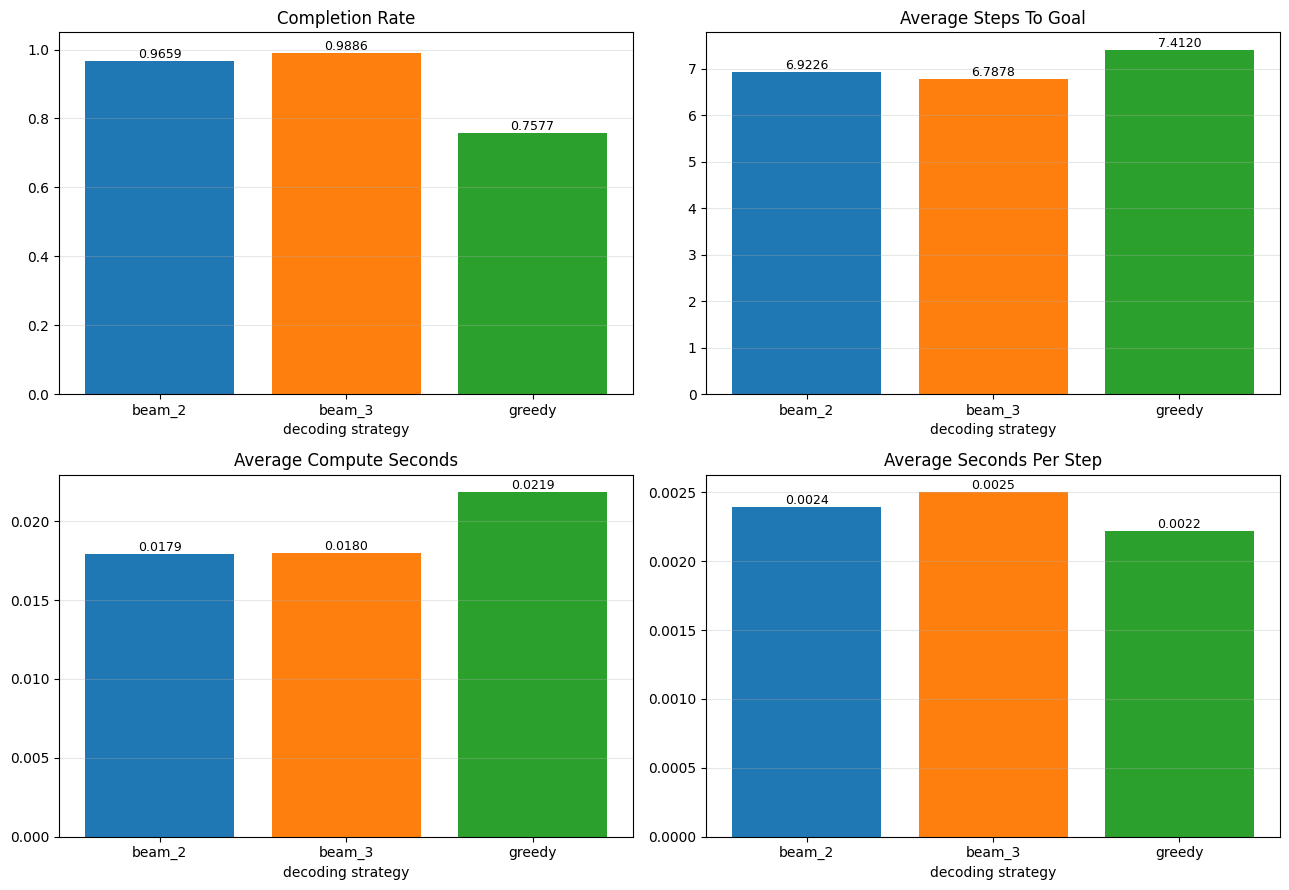

In [132]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
metric_specs = [
    ("completion_rate", "Completion Rate"),
    ("average_steps_to_goal", "Average Steps To Goal"),
    ("average_compute_seconds", "Average Compute Seconds"),
    ("average_seconds_per_step", "Average Seconds Per Step"),
]

for ax, (metric, title) in zip(np.asarray(axes).ravel(), metric_specs):
    ax.bar(heldout_summary["strategy"], heldout_summary[metric], color=["tab:blue", "tab:orange", "tab:green"])
    ax.set_title(title)
    ax.set_xlabel("decoding strategy")
    ax.grid(axis="y", alpha=0.3)
    if metric == "completion_rate":
        ax.set_ylim(0.0, 1.05)
    for x_pos, value in enumerate(heldout_summary[metric]):
        ax.text(x_pos, float(value), f"{float(value):.4f}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()


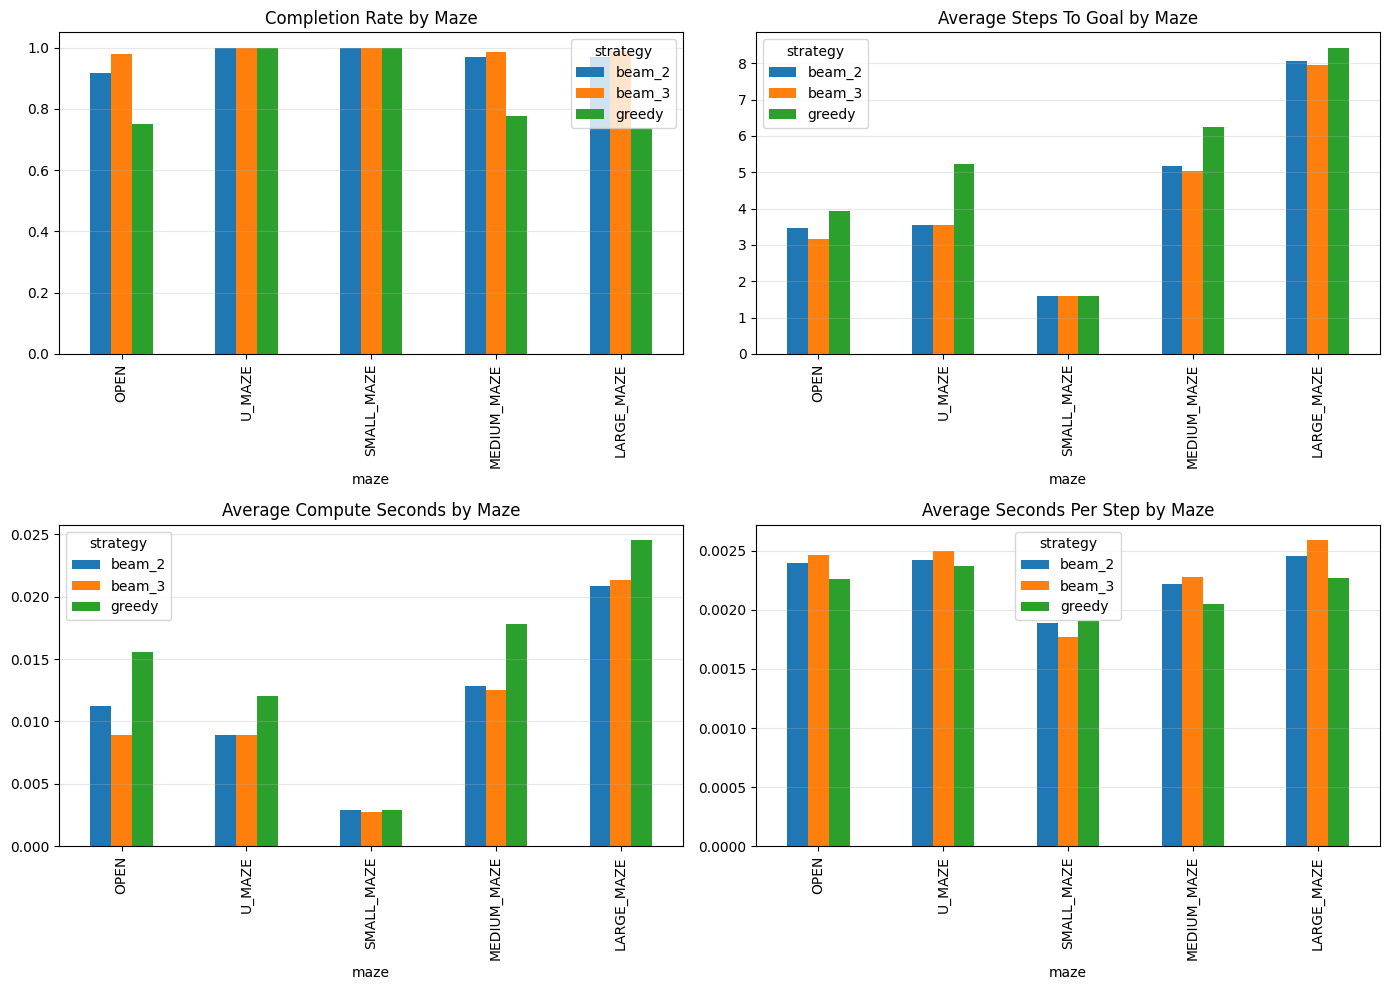

In [133]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
per_maze_plot = heldout_per_maze_summary[heldout_per_maze_summary["maze_name"].isin(["OPEN", "U_MAZE", "SMALL_MAZE", "MEDIUM_MAZE", "LARGE_MAZE"])].copy()
metric_specs = [
    ("completion_rate", "Completion Rate"),
    ("average_steps_to_goal", "Average Steps To Goal"),
    ("average_compute_seconds", "Average Compute Seconds"),
    ("average_seconds_per_step", "Average Seconds Per Step"),
]

for ax, (metric, title) in zip(np.asarray(axes).ravel(), metric_specs):
    pivot = per_maze_plot.pivot(index="maze_name", columns="strategy", values=metric).loc[["OPEN", "U_MAZE", "SMALL_MAZE", "MEDIUM_MAZE", "LARGE_MAZE"]]
    pivot.plot(kind="bar", ax=ax)
    ax.set_title(title + " by Maze")
    ax.set_xlabel("maze")
    ax.grid(axis="y", alpha=0.3)
    if metric == "completion_rate":
        ax.set_ylim(0.0, 1.05)

plt.tight_layout()
plt.show()


In [134]:
def heldout_state_token(cell_xy):
    return int(heldout_state_token_offset + int(cell_xy[0]) * heldout_global_grid_shape[1] + int(cell_xy[1]))


def heldout_valid_action_candidates(current_cell, maze):
    deltas = np.asarray([[0, 1], [0, -1], [-1, 0], [1, 0], [0, 0]], dtype=np.int16)
    candidates = []
    for action_idx, delta in enumerate(deltas):
        next_cell = np.asarray(current_cell, dtype=np.int16) + delta
        inside = 0 <= int(next_cell[0]) < maze.shape[0] and 0 <= int(next_cell[1]) < maze.shape[1]
        if inside and maze[int(next_cell[0]), int(next_cell[1])] == 0:
            candidates.append((action_idx, next_cell.astype(np.int16)))
    return candidates


def heldout_batched_next_action_logits(token_batches, type_batches):
    max_len = max(len(tokens) for tokens in token_batches)
    input_ids = np.zeros((len(token_batches), max_len), dtype=np.int64)
    token_type_ids = np.zeros((len(token_batches), max_len), dtype=np.int64)
    attention_mask = np.zeros((len(token_batches), max_len), dtype=np.bool_)

    for row, (tokens, types) in enumerate(zip(token_batches, type_batches)):
        seq_len = len(tokens)
        input_ids[row, :seq_len] = np.asarray(tokens, dtype=np.int64)
        token_type_ids[row, :seq_len] = np.asarray(types, dtype=np.int64)
        attention_mask[row, :seq_len] = True

    with torch.no_grad():
        logits = heldout_model(
            input_ids=torch.from_numpy(input_ids),
            token_type_ids=torch.from_numpy(token_type_ids),
            attention_mask=torch.from_numpy(attention_mask),
        )

    last_logits = []
    for row, tokens in enumerate(token_batches):
        last_logits.append(
            logits[row, len(tokens) - 1, heldout_action_token_offset: heldout_action_token_offset + 5].cpu().numpy()
        )
    return np.asarray(last_logits, dtype=np.float32)


def heldout_greedy_rollout(maze_index, start_cell, goal_cell, max_steps):
    maze = heldout_mazes[int(maze_index)]
    path = [np.asarray(start_cell, dtype=np.int16)]
    tokens = [
        int(heldout_maze_token_ids[int(maze_index)]),
        heldout_state_token(start_cell),
        heldout_state_token(goal_cell),
        heldout_state_token(start_cell),
    ]
    types = [1, 2, 3, 4]

    for _ in range(int(min(max_steps, heldout_max_rollout_steps))):
        action_logits = heldout_batched_next_action_logits([tokens], [types])[0]
        best_idx, best_next = max(
            heldout_valid_action_candidates(path[-1], maze),
            key=lambda item: float(action_logits[item[0]]),
        )
        tokens.extend([heldout_action_token_offset + best_idx, heldout_state_token(best_next)])
        types.extend([5, 4])
        path.append(best_next)
        if np.array_equal(best_next, goal_cell):
            break
    return np.asarray(path, dtype=np.int16)


def heldout_beam_rollout(maze_index, start_cell, goal_cell, max_steps, beam_width):
    maze = heldout_mazes[int(maze_index)]
    start_state_token = heldout_state_token(start_cell)
    goal_state_token = heldout_state_token(goal_cell)
    beams = [{
        "tokens": [int(heldout_maze_token_ids[int(maze_index)]), start_state_token, goal_state_token, start_state_token],
        "types": [1, 2, 3, 4],
        "path": [np.asarray(start_cell, dtype=np.int16)],
        "score": 0.0,
        "done": False,
    }]

    for _ in range(int(min(max_steps, heldout_max_rollout_steps))):
        active = [beam for beam in beams if not beam["done"]]
        if not active:
            break
        logits_batch = heldout_batched_next_action_logits(
            [beam["tokens"] for beam in active],
            [beam["types"] for beam in active],
        )

        candidates = []
        active_cursor = 0
        for beam in beams:
            if beam["done"]:
                candidates.append(beam)
                continue
            action_logits = logits_batch[active_cursor]
            active_cursor += 1
            for action_idx, next_cell in heldout_valid_action_candidates(beam["path"][-1], maze):
                candidates.append({
                    "tokens": list(beam["tokens"]) + [heldout_action_token_offset + action_idx, heldout_state_token(next_cell)],
                    "types": list(beam["types"]) + [5, 4],
                    "path": list(beam["path"]) + [np.asarray(next_cell, dtype=np.int16)],
                    "score": float(beam["score"]) + float(action_logits[action_idx]),
                    "done": bool(np.array_equal(next_cell, goal_cell)),
                })

        beams = sorted(candidates, key=lambda beam: float(beam["score"]), reverse=True)[:beam_width]
        finished = [beam for beam in beams if beam["done"]]
        if finished:
            return np.asarray(max(finished, key=lambda beam: float(beam["score"]))["path"], dtype=np.int16)

    return np.asarray(max(beams, key=lambda beam: float(beam["score"]))["path"], dtype=np.int16)


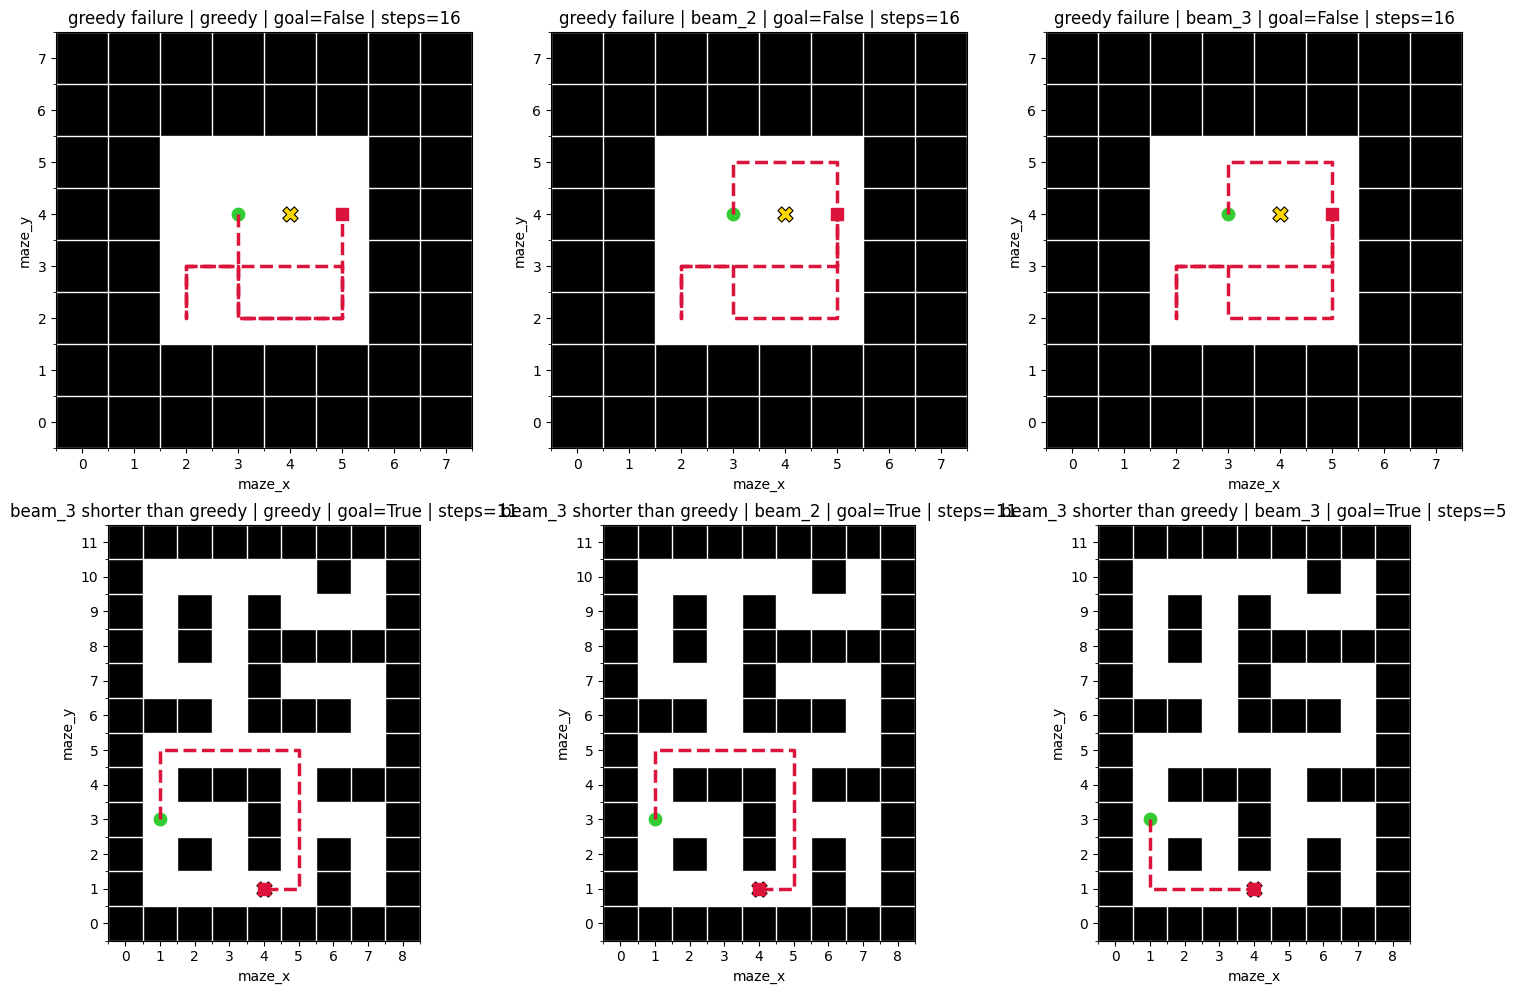

,kind,maze_name,episode_id,start_cell,goal_cell,requested_steps
0,greedy failure,OPEN,99,"[3, 4]","[4, 4]",16
1,beam_3 shorter than greedy,LARGE_MAZE,1856,"[1, 3]","[4, 1]",16


In [135]:
example_rows = []

failed_greedy = heldout_results[(heldout_results["strategy"] == "greedy") & (~heldout_results["goal_reached"])].head(1)
better_beam = (
    heldout_results.pivot_table(
        index=["maze_name", "episode_id", "query_index", "start_x", "start_y", "goal_x", "goal_y"],
        columns="strategy",
        values=["goal_reached", "steps_until_stop"],
        aggfunc="first",
    )
    .reset_index()
)
better_beam.columns = [
    "_".join(col).strip("_") if isinstance(col, tuple) else col
    for col in better_beam.columns.to_flat_index()
]
better_beam = better_beam[
    better_beam["goal_reached_greedy"]
    & better_beam["goal_reached_beam_3"]
    & (better_beam["steps_until_stop_beam_3"] < better_beam["steps_until_stop_greedy"])
].head(1)

selected_queries = []
if len(failed_greedy):
    selected_queries.append({
        "kind": "greedy failure",
        "maze_name": str(failed_greedy.iloc[0]["maze_name"]),
        "query_index": int(failed_greedy.iloc[0]["query_index"]),
    })
if len(better_beam):
    selected_queries.append({
        "kind": "beam_3 shorter than greedy",
        "maze_name": str(better_beam.iloc[0]["maze_name"]),
        "query_index": int(better_beam.iloc[0]["query_index"]),
    })

fig, axes = plt.subplots(len(selected_queries), 3, figsize=(15, 5 * max(len(selected_queries), 1)))
if len(selected_queries) == 1:
    axes = np.asarray([axes])

for row_idx, query in enumerate(selected_queries):
    query_index = int(query["query_index"])
    maze_index = int(heldout_maze_indices[query_index])
    maze = heldout_mazes[maze_index]
    start_cell = np.asarray(heldout_start_cells[query_index], dtype=np.int16)
    goal_cell = np.asarray(heldout_goal_cells[query_index], dtype=np.int16)
    requested_steps = max(2 * int(heldout_path_lengths[query_index]), 16)
    greedy_path = heldout_greedy_rollout(maze_index, start_cell, goal_cell, requested_steps)
    beam2_path = heldout_beam_rollout(maze_index, start_cell, goal_cell, requested_steps, beam_width=2)
    beam3_path = heldout_beam_rollout(maze_index, start_cell, goal_cell, requested_steps, beam_width=3)
    strategy_paths = [("greedy", greedy_path), ("beam_2", beam2_path), ("beam_3", beam3_path)]

    for col_idx, (strategy_name, pred_path) in enumerate(strategy_paths):
        ax = axes[row_idx, col_idx]
        overlay = np.ones((maze.shape[1], maze.shape[0], 3), dtype=np.float32)
        overlay[maze.T == 1] = np.array([0.0, 0.0, 0.0], dtype=np.float32)
        ax.imshow(overlay, origin="lower", extent=(-0.5, maze.shape[0] - 0.5, -0.5, maze.shape[1] - 0.5))
        ax.plot(pred_path[:, 0], pred_path[:, 1], color="crimson", linewidth=2.5, linestyle="--")
        ax.scatter(start_cell[0], start_cell[1], c="limegreen", s=80, label="start")
        ax.scatter(goal_cell[0], goal_cell[1], c="gold", s=120, marker="X", edgecolors="black", linewidths=0.8, label="goal")
        ax.scatter(pred_path[-1, 0], pred_path[-1, 1], c="crimson", s=70, marker="s", label="model end")
        reached_goal = bool(np.array_equal(pred_path[-1], goal_cell))
        ax.set_title(f"{query['kind']} | {strategy_name} | goal={reached_goal} | steps={max(len(pred_path)-1, 0)}")
        ax.set_xticks(np.arange(maze.shape[0]))
        ax.set_yticks(np.arange(maze.shape[1]))
        ax.set_xticks(np.arange(-0.5, maze.shape[0], 1), minor=True)
        ax.set_yticks(np.arange(-0.5, maze.shape[1], 1), minor=True)
        ax.grid(which="minor", color="white", linewidth=1.0)
        ax.set_xlabel("maze_x")
        ax.set_ylabel("maze_y")

    example_rows.append({
        "kind": query["kind"],
        "maze_name": heldout_maze_name_per_episode[query_index],
        "episode_id": int(heldout_episode_ids[query_index]),
        "start_cell": start_cell.tolist(),
        "goal_cell": goal_cell.tolist(),
        "requested_steps": int(requested_steps),
    })

plt.tight_layout()
plt.show()

pd.DataFrame(example_rows)

## 5-fold cross-validation decoding evaluation

This section reports decoding performance under deterministic 5-fold cross-validation over the full dataset. Each exact `(maze, start, goal)` query is evaluated once as a held-out fold and trained on in the other four folds.


In [136]:
CV5_DATASET_PATH = Path("maze2d_all_mazes_transformer_ready_cv5.npz")
CV5_RESULTS_CSV = Path("beam_search_benchmark_cv5_results.csv")
CV5_SUMMARY_CSV = Path("beam_search_benchmark_cv5_summary.csv")
CV5_PER_MAZE_SUMMARY_CSV = Path("beam_search_benchmark_cv5_per_maze_summary.csv")
CV5_FOLD_MEAN_STD_CSV = Path("beam_search_benchmark_cv5_fold_mean_std.csv")

cv5_dataset = np.load(CV5_DATASET_PATH, allow_pickle=True)
cv5_results = pd.read_csv(CV5_RESULTS_CSV)
cv5_summary = pd.read_csv(CV5_SUMMARY_CSV)
cv5_per_maze_summary = pd.read_csv(CV5_PER_MAZE_SUMMARY_CSV)
cv5_fold_mean_std = pd.read_csv(CV5_FOLD_MEAN_STD_CSV)

print({
    "dataset": str(CV5_DATASET_PATH),
    "num_folds": int(cv5_dataset["cv_num_folds"][0]),
    "num_queries_total": int(len(cv5_results) // 3),
    "results_rows": int(len(cv5_results)),
})

cv5_summary

{'dataset': 'maze2d_all_mazes_transformer_ready_cv5.npz', 'num_folds': 5, 'num_queries_total': 3074, 'results_rows': 9222}


,strategy,completion_rate,average_steps_to_goal,average_compute_seconds,average_seconds_per_step
0,beam_2,0.959987,7.015588,0.027276,0.003564
1,beam_3,0.992193,6.821311,0.026600,0.003714
2,greedy,0.758946,7.502786,0.032782,0.003265


In [137]:
display(cv5_fold_mean_std)
display(cv5_per_maze_summary)


,strategy,completion_rate_mean,completion_rate_std,average_steps_to_goal_mean,average_steps_to_goal_std,average_compute_seconds_mean,average_compute_seconds_std,average_seconds_per_step_mean,average_seconds_per_step_std
0,beam_2,0.959988,0.004528,7.015485,0.047507,0.027275,0.003613,0.003564,0.000711
1,beam_3,0.992190,0.004940,6.821339,0.035612,0.026600,0.003272,0.003714,0.000691
2,greedy,0.758942,0.029474,7.500308,0.181952,0.032781,0.005086,0.003265,0.000632


,maze_name,strategy,completion_rate,average_steps_to_goal,average_compute_seconds,average_seconds_per_step
0,LARGE_MAZE,beam_2,0.959420,8.189829,0.031148,0.003499
1,LARGE_MAZE,beam_3,0.993237,7.973735,0.030773,0.003668
2,LARGE_MAZE,greedy,0.729469,8.588742,0.035871,0.003187
3,MEDIUM_MAZE,beam_2,0.960000,5.275641,0.021274,0.003557
4,MEDIUM_MAZE,beam_3,0.987692,5.119938,0.020342,0.003723
5,MEDIUM_MAZE,greedy,0.800000,5.975000,0.026881,0.003243
6,OPEN,beam_2,0.945833,3.409692,0.017451,0.004175
7,OPEN,beam_3,0.991667,3.168067,0.014305,0.004149
8,OPEN,greedy,0.808333,4.680412,0.028125,0.003931
9,SMALL_MAZE,beam_2,1.000000,1.666667,0.005001,0.002966


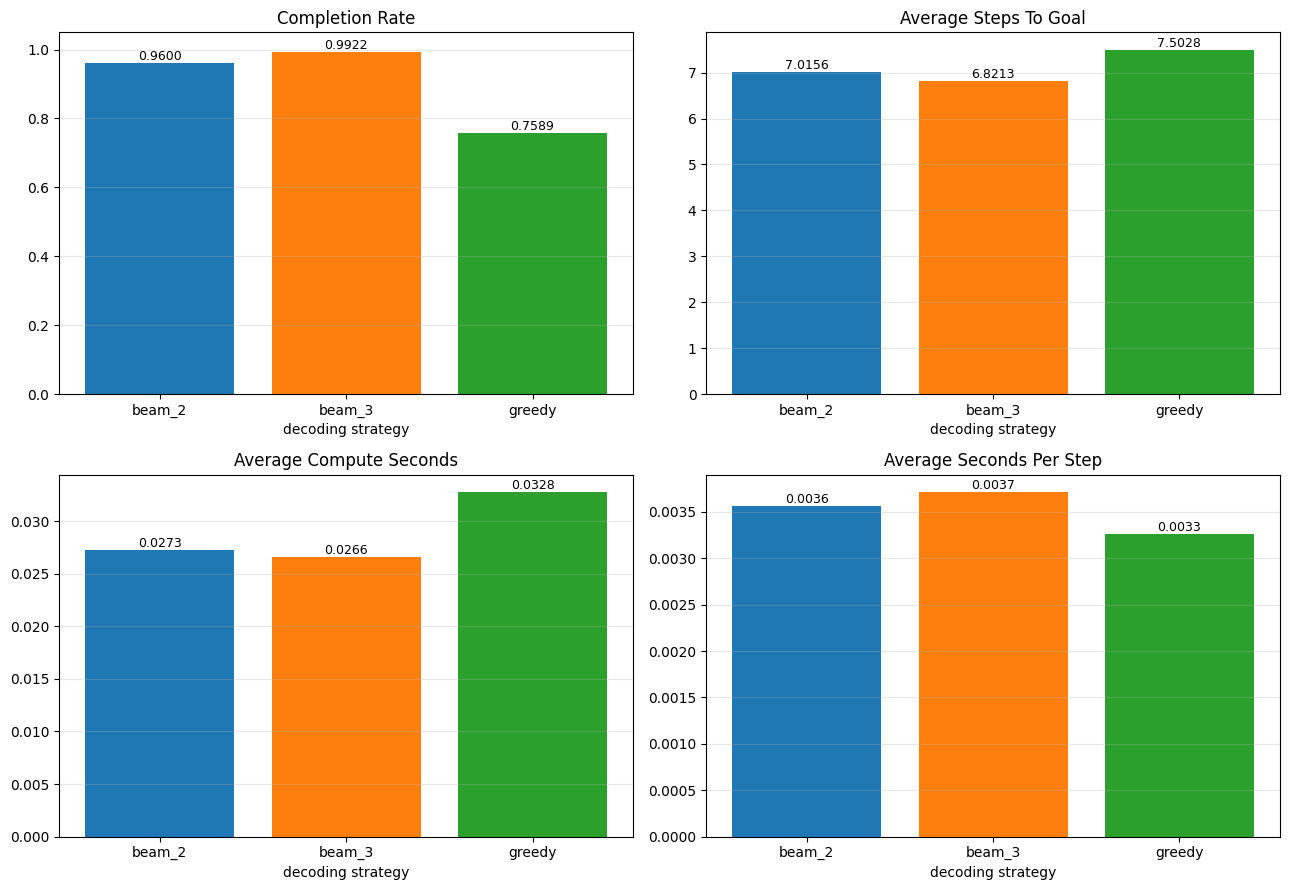

In [138]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
metric_specs = [
    ("completion_rate", "Completion Rate"),
    ("average_steps_to_goal", "Average Steps To Goal"),
    ("average_compute_seconds", "Average Compute Seconds"),
    ("average_seconds_per_step", "Average Seconds Per Step"),
]

for ax, (metric, title) in zip(np.asarray(axes).ravel(), metric_specs):
    ax.bar(cv5_summary["strategy"], cv5_summary[metric], color=["tab:blue", "tab:orange", "tab:green"])
    ax.set_title(title)
    ax.set_xlabel("decoding strategy")
    ax.grid(axis="y", alpha=0.3)
    if metric == "completion_rate":
        ax.set_ylim(0.0, 1.05)
    for x_pos, value in enumerate(cv5_summary[metric]):
        ax.text(x_pos, float(value), f"{float(value):.4f}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()


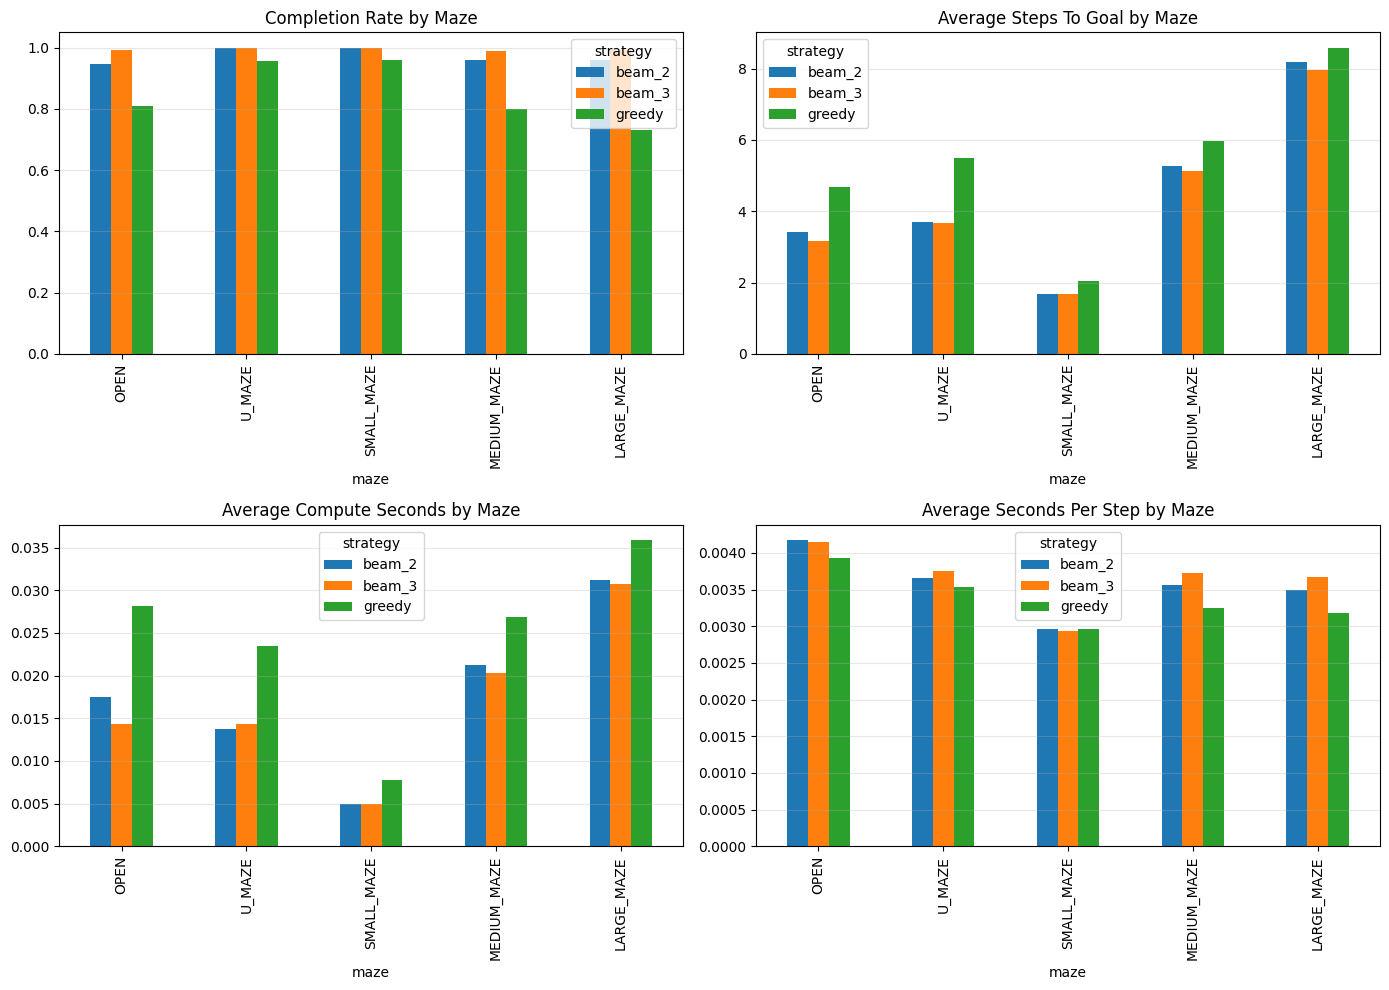

In [139]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
per_maze_plot = cv5_per_maze_summary[cv5_per_maze_summary["maze_name"].isin(["OPEN", "U_MAZE", "SMALL_MAZE", "MEDIUM_MAZE", "LARGE_MAZE"])].copy()
metric_specs = [
    ("completion_rate", "Completion Rate"),
    ("average_steps_to_goal", "Average Steps To Goal"),
    ("average_compute_seconds", "Average Compute Seconds"),
    ("average_seconds_per_step", "Average Seconds Per Step"),
]

for ax, (metric, title) in zip(np.asarray(axes).ravel(), metric_specs):
    pivot = per_maze_plot.pivot(index="maze_name", columns="strategy", values=metric).loc[["OPEN", "U_MAZE", "SMALL_MAZE", "MEDIUM_MAZE", "LARGE_MAZE"]]
    pivot.plot(kind="bar", ax=ax)
    ax.set_title(title + " by Maze")
    ax.set_xlabel("maze")
    ax.grid(axis="y", alpha=0.3)
    if metric == "completion_rate":
        ax.set_ylim(0.0, 1.05)

plt.tight_layout()
plt.show()
